In [1]:
import os
import pandas as pd
import numpy as np
import nibabel as nib
import shapeworks as sw
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from contextlib import redirect_stdout, redirect_stderr, contextmanager, ExitStack

@contextmanager
def suppress_stdout(out=True, err=False):
    with ExitStack() as stack:
        with open(os.devnull, "w") as null:
            if out:
                stack.enter_context(redirect_stdout(null))
            if err:
                stack.enter_context(redirect_stderr(null))
            yield

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## 1. Data Discovery and Statistics

In [2]:
# Set paths
adni_data_path = "/home/jakaria/ADNI/ADNI_1"
output_dir = "/home/jakaria/ADNI/ADNI_1/adni_processed/"
os.makedirs(output_dir, exist_ok=True)

# Find all hippocampus mask files
mask_files = glob(os.path.join(adni_data_path, "**/*.nii*"), recursive=True)
print(f"Total hippocampus mask files found: {len(mask_files)}")
print(f"\nFirst 5 files:")
for f in mask_files[:5]:
    print(f)

Total hippocampus mask files found: 6528

First 5 files:
/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask/ADNI/133_S_1170/Hippocampal_Mask/2008-01-17_12_04_22.0/I147708/ADNI_133_S_1170_MR_Hippocampal_Mask_Hi_20090702084102707_S44696_I147708.nii
/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask/ADNI/133_S_1170/Hippocampal_Mask/2007-07-30_10_00_49.0/I147707/ADNI_133_S_1170_MR_Hippocampal_Mask_Hi_20090702084037535_S36563_I147707.nii
/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask/ADNI/133_S_1170/Hippocampal_Mask/2007-07-30_13_47_22.0/I147706/ADNI_133_S_1170_MR_Hippocampal_Mask_Hi_20090702084011815_S36669_I147706.nii
/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask/ADNI/133_S_1170/Hippocampal_Mask/2007-01-16_13_48_27.0/I147705/ADNI_133_S_1170_MR_Hippocampal_Mask_Hi_20090702083947065_S25256_I147705.nii
/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask/ADNI/133_S_1170/Hippocampal_Mask/2008-01-29_12_22_33.0/I147709/ADNI_133_S_1170_MR_Hippocampal_Mask_Hi_20090702084127926_S45064_I147709.ni

In [3]:
# Load metadata and diagnosis CSV
metadata_files = glob(os.path.join(adni_data_path, "*.csv"))
print(f"CSV files found: {metadata_files}")

# Load the ADNI hippocampus metadata
if len(metadata_files) > 0:
    diagnosis_df = pd.read_csv(metadata_files[0])
    print(f"\n{os.path.basename(metadata_files[0])} columns: {diagnosis_df.columns.tolist()}")
    print(f"Shape: {diagnosis_df.shape}")
    
    # Keep only required columns and rename them
    diagnosis_df = diagnosis_df[['Subject', 'Group', 'Sex', 'Age', 'Visit', 'Image Data ID']].copy()
    diagnosis_df = diagnosis_df.rename(columns={
        'Subject': 'subject_id',
        'Group': 'diagnosis',
        'Sex': 'gender',
        'Age': 'age',
        'Visit': 'visit',
        'Image Data ID': 'image_data_id'
    })
    
    print(f"\n\nDiagnosis distribution:")
    print(diagnosis_df['diagnosis'].value_counts())
    
    print(f"\n\nGender distribution:")
    print(diagnosis_df['gender'].value_counts())
    
    print(f"\n\nAge statistics:")
    print(diagnosis_df['age'].describe())
    
    print(f"\n\nVisit distribution:")
    print(diagnosis_df['visit'].value_counts())
    
    print(f"\n\nUnique subjects in CSV: {diagnosis_df['subject_id'].nunique()}")
else:
    diagnosis_df = None
    print("No CSV files found!")

CSV files found: ['/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask_12_17_2025.csv']

ADNI_1_Hippocampal_Mask_12_17_2025.csv columns: ['Image Data ID', 'Subject', 'Group', 'Sex', 'Age', 'Visit', 'Modality', 'Description', 'Type', 'Acq Date', 'Format', 'Downloaded']
Shape: (1632, 12)


Diagnosis distribution:
diagnosis
MCI    813
CN     477
AD     342
Name: count, dtype: int64


Gender distribution:
gender
M    904
F    728
Name: count, dtype: int64


Age statistics:
count    1632.000000
mean       76.118873
std         6.699330
min        55.000000
25%        72.000000
50%        76.000000
75%        81.000000
max        91.000000
Name: age, dtype: float64


Visit distribution:
visit
m06     543
m12     542
sc      480
bl       66
uns1      1
Name: count, dtype: int64


Unique subjects in CSV: 489


In [4]:
# Save the filtered metadata to a new CSV file
if diagnosis_df is not None:
    output_metadata_csv = os.path.join(output_dir, "adni_metadata_filtered.csv")
    diagnosis_df.to_csv(output_metadata_csv, index=False)
    print(f"Filtered metadata saved to: {output_metadata_csv}")
    print(f"Shape: {diagnosis_df.shape}")
    print(f"Columns: {diagnosis_df.columns.tolist()}")
    print(f"\nFirst 10 rows:")
    print(diagnosis_df.head(10))
else:
    print("No diagnosis data available to save.")

Filtered metadata saved to: /home/jakaria/ADNI/ADNI_1/adni_processed/adni_metadata_filtered.csv
Shape: (1632, 6)
Columns: ['subject_id', 'diagnosis', 'gender', 'age', 'visit', 'image_data_id']

First 10 rows:
   subject_id diagnosis gender  age visit image_data_id
0  002_S_0954       MCI      F   69    sc        I85433
1  005_S_0572       MCI      M   79    bl        I85434
2  005_S_0324       MCI      F   75    bl        I91387
3  005_S_0324       MCI      F   76   m06        I91388
4  005_S_0324       MCI      F   76   m12        I91389
5  007_S_0101       MCI      M   74    sc        I91390
6  007_S_0101       MCI      M   74   m06        I91391
7  007_S_0101       MCI      M   75   m12        I91392
8  005_S_0448       MCI      M   86    sc        I93352
9  005_S_0448       MCI      M   86   m06        I93354


## 2. Explore NIfTI File Structure and Hippocampus Labels

In [3]:
# Explore NIfTI file structure to identify hippocampus labels across ALL files

if len(mask_files) > 0:
    print("="*80)
    print("ANALYZING LABELS ACROSS ALL FILES")
    print("="*80)
    print(f"\nTotal files to analyze: {len(mask_files)}")
    
    # Dictionary to store label sets and their counts
    from collections import defaultdict
    label_set_counts = defaultdict(int)
    label_set_examples = defaultdict(list)
    all_unique_labels = set()
    
    # Analyze all files
    print("\nScanning all files for label patterns...")
    
    for file_path in tqdm(mask_files, desc="Analyzing labels"):
        try:
            img = nib.load(file_path)
            data = img.get_fdata()
            labels = tuple(sorted(np.unique(data[data > 0])))  # Only non-zero labels, sorted
            
            # Track this label set
            label_set_counts[labels] += 1
            all_unique_labels.update(labels)
            
            # Store example files for each label set (up to 3 examples)
            if len(label_set_examples[labels]) < 3:
                label_set_examples[labels].append(os.path.basename(file_path))
                
        except Exception as e:
            print(f"\nError processing {os.path.basename(file_path)}: {e}")
            continue
    
    # Report findings
    print(f"\n{'='*80}")
    print("LABEL ANALYSIS RESULTS")
    print(f"{'='*80}")
    
    print(f"\nAll unique labels found across dataset: {sorted(all_unique_labels)}")
    print(f"Number of different label combinations: {len(label_set_counts)}")
    
    print(f"\n{'='*80}")
    print("LABEL COMBINATIONS FOUND:")
    print(f"{'='*80}")
    
    # Sort by frequency
    sorted_label_sets = sorted(label_set_counts.items(), key=lambda x: x[1], reverse=True)
    
    for i, (label_set, count) in enumerate(sorted_label_sets, 1):
        percentage = (count / len(mask_files)) * 100
        print(f"\n{i}. Labels: {label_set}")
        print(f"   Count: {count} files ({percentage:.1f}%)")
        print(f"   Examples:")
        for example in label_set_examples[label_set]:
            print(f"     - {example}")
    
    # Detailed analysis of the most common label set
    print(f"\n{'='*80}")
    print("DETAILED ANALYSIS OF MOST COMMON LABEL SET")
    print(f"{'='*80}")
    
    most_common_labels = sorted_label_sets[0][0]
    example_file = None
    
    # Find an example file with this label set
    for file_path in mask_files:
        try:
            img = nib.load(file_path)
            data = img.get_fdata()
            labels = tuple(sorted(np.unique(data[data > 0])))
            if labels == most_common_labels:
                example_file = file_path
                break
        except:
            continue
    
    if example_file:
        print(f"\nExample file: {os.path.basename(example_file)}")
        
        # Load and analyze
        nifti_img = nib.load(example_file)
        nifti_data = nifti_img.get_fdata()
        
        print(f"\nImage properties:")
        print(f"  Shape: {nifti_data.shape}")
        print(f"  Data type: {nifti_data.dtype}")
        print(f"  Voxel dimensions (mm): {nifti_img.header.get_zooms()}")
        
        print(f"\nLabel distribution in this file:")
        for label in most_common_labels:
            mask = (nifti_data == label)
            count = np.sum(mask)
            percentage = (count / nifti_data.size) * 100
            
            # Calculate spatial center
            coords = np.where(mask)
            if len(coords[0]) > 0:
                center = [np.mean(c) for c in coords]
                print(f"\n  Label {label}:")
                print(f"    Voxels: {count:,} ({percentage:.2f}%)")
                print(f"    Center: X={center[0]:.1f}, Y={center[1]:.1f}, Z={center[2]:.1f}")
    
    # Summary and recommendations
    print(f"\n{'='*80}")
    print("SUMMARY & RECOMMENDATIONS")
    print(f"{'='*80}")
    
    if len(sorted_label_sets) == 1:
        labels = sorted_label_sets[0][0]
        print(f"\n✓ CONSISTENT: All {len(mask_files)} files use the same labels: {labels}")
        if len(labels) == 2:
            print(f"✓ Each file has 2 hippocampus structures (left and right)")
            print(f"✓ Separation logic should work correctly")
        else:
            print(f"⚠ WARNING: Expected 2 labels, found {len(labels)}")
    else:
        print(f"\n⚠ INCONSISTENT: Found {len(sorted_label_sets)} different label combinations")
        print(f"\nMost common ({sorted_label_sets[0][1]} files): {sorted_label_sets[0][0]}")
        if len(sorted_label_sets) > 1:
            print(f"Second most common ({sorted_label_sets[1][1]} files): {sorted_label_sets[1][0]}")
        print(f"\n⚠ Separation logic must handle multiple label schemes!")
    
    print(f"\n{'='*80}")
    
else:
    print("No NIfTI files found!")

ANALYZING LABELS ACROSS ALL FILES

Total files to analyze: 6528

Scanning all files for label patterns...


Analyzing labels:   3%|▎         | 187/6528 [00:07<04:07, 25.62it/s]


KeyboardInterrupt: 

In [5]:
# CRITICAL VERIFICATION: Match NIfTI labels with XML volumes to determine left vs right
print("="*80)
print("VERIFYING LEFT/RIGHT LABELS BY COMPARING WITH XML GROUND TRUTH")
print("="*80)

import xml.etree.ElementTree as ET
import re

# Target XML file
xml_file = "/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask_IDA_Metadata/ADNI/ADNI_128_S_0138_Hippocampal_Mask_S18461_I147548.xml"

print(f"\nLoading XML file: {os.path.basename(xml_file)}")

# Extract Image ID from XML filename
xml_basename = os.path.basename(xml_file)
image_id_match = re.search(r'I\d+', xml_basename)
if image_id_match:
    image_id = image_id_match.group(0)
    print(f"Image ID from XML: {image_id}")
else:
    print("❌ Could not extract Image ID from XML filename")
    image_id = None

# Parse XML to get ground truth volumes
tree = ET.parse(xml_file)
root = tree.getroot()

# Extract volumes
ns = {'': 'http://www.loni.usc.edu/resource/xml/hippo/v1'}
derived_measures = root.findall('.//derivedMeasure', ns) or root.findall('.//derivedMeasure')

xml_volumes = {}
for measure in derived_measures:
    structure_elem = measure.find('.//measuredStructure', ns) or measure.find('.//measuredStructure')
    if structure_elem is not None and 'Hippocampus' in structure_elem.text:
        hemisphere_elem = measure.find('.//measuredHemisphere', ns) or measure.find('.//measuredHemisphere')
        value_elem = measure.find('.//measureValue', ns) or measure.find('.//measureValue')
        
        if hemisphere_elem is not None and value_elem is not None:
            hemisphere = hemisphere_elem.text.strip()
            volume = float(value_elem.text)
            xml_volumes[hemisphere] = volume

print(f"\n✓ XML Ground Truth Volumes:")
print(f"  Left Hippocampus:  {xml_volumes.get('Left', 'N/A')} mm³")
print(f"  Right Hippocampus: {xml_volumes.get('Right', 'N/A')} mm³")

# Find corresponding NIfTI file using Image ID
nifti_file = None
if image_id:
    print(f"\nSearching for NIfTI file with Image ID: {image_id}")
    for mask_file in mask_files:
        if image_id in mask_file:
            nifti_file = mask_file
            print(f"  ✓ Found: {os.path.basename(mask_file)}")
            break

if nifti_file is None:
    print(f"\n❌ ERROR: Could not find NIfTI file for Image ID: {image_id}")
    print(f"Available files (first 10):")
    for f in mask_files[:10]:
        print(f"  {os.path.basename(f)}")
else:
    print(f"\n✓ Found NIfTI file: {os.path.basename(nifti_file)}")
    
    # Load NIfTI and calculate volumes for each label
    print(f"\n{'='*80}")
    print("CALCULATING VOLUMES FROM NIFTI FILE")
    print(f"{'='*80}")
    
    nifti_img = nib.load(nifti_file)
    nifti_data = nifti_img.get_fdata()
    voxel_dims = nifti_img.header.get_zooms()
    voxel_volume = voxel_dims[0] * voxel_dims[1] * voxel_dims[2]  # mm³ per voxel
    
    print(f"\nImage properties:")
    print(f"  Shape: {nifti_data.shape}")
    print(f"  Voxel dimensions: {voxel_dims[:3]} mm")
    print(f"  Voxel volume: {voxel_volume:.4f} mm³")
    
    # Get labels
    unique_labels = np.unique(nifti_data)
    non_zero_labels = unique_labels[unique_labels > 0]
    
    print(f"\nLabels found: {non_zero_labels}")
    
    # Calculate volume and center for each label
    label_info = {}
    for label in non_zero_labels:
        mask = (nifti_data == label)
        voxel_count = np.sum(mask)
        volume_mm3 = voxel_count * voxel_volume
        
        # Get spatial center
        coords = np.where(mask)
        center_x = np.mean(coords[0]) if len(coords[0]) > 0 else 0
        center_y = np.mean(coords[1]) if len(coords[0]) > 0 else 0
        center_z = np.mean(coords[2]) if len(coords[0]) > 0 else 0
        
        label_info[label] = {
            'voxel_count': voxel_count,
            'volume_mm3': volume_mm3,
            'center_x': center_x,
            'center_y': center_y,
            'center_z': center_z
        }
        
        print(f"\nLabel {label}:")
        print(f"  Voxels: {voxel_count:,}")
        print(f"  Volume: {volume_mm3:.2f} mm³")
        print(f"  Center: X={center_x:.1f}, Y={center_y:.1f}, Z={center_z:.1f}")
    
    # Match calculated volumes with XML volumes
    print(f"\n{'='*80}")
    print("MATCHING LABELS WITH XML VOLUMES")
    print(f"{'='*80}")
    
    xml_left = xml_volumes.get('Left', 0)
    xml_right = xml_volumes.get('Right', 0)
    
    # Find which label matches which side based on volume
    best_match = {}
    for label, info in label_info.items():
        calc_vol = info['volume_mm3']
        
        diff_left = abs(calc_vol - xml_left)
        diff_right = abs(calc_vol - xml_right)
        
        if diff_left < diff_right:
            best_match[label] = 'Left'
            match_quality = (diff_left / xml_left) * 100
        else:
            best_match[label] = 'Right'
            match_quality = (diff_right / xml_right) * 100
        
        print(f"\nLabel {label} (Volume: {calc_vol:.2f} mm³):")
        print(f"  Difference from XML Left:  {diff_left:.2f} mm³ ({(diff_left/xml_left)*100:.1f}%)")
        print(f"  Difference from XML Right: {diff_right:.2f} mm³ ({(diff_right/xml_right)*100:.1f}%)")
        print(f"  ✓ BEST MATCH: {best_match[label]} ({match_quality:.1f}% error)")
        print(f"  X-coordinate: {info['center_x']:.1f}")
    
    # Determine orientation convention
    print(f"\n{'='*80}")
    print("DETERMINING ORIENTATION CONVENTION")
    print(f"{'='*80}")
    
    # Find which label is left and which is right
    left_label = None
    right_label = None
    for label, side in best_match.items():
        if side == 'Left':
            left_label = label
        else:
            right_label = label
    
    if left_label is not None and right_label is not None:
        left_x = label_info[left_label]['center_x']
        right_x = label_info[right_label]['center_x']
        
        print(f"\nLabel {left_label} = LEFT:  X-coordinate = {left_x:.1f}")
        print(f"Label {right_label} = RIGHT: X-coordinate = {right_x:.1f}")
        print(f"\nX-coordinate difference: {left_x - right_x:.1f}")
        
        if left_x > right_x:
            print(f"\n✓ ORIENTATION: LEFT has LARGER X-coordinate")
            print(f"  This confirms: Larger X = Left, Smaller X = Right")
            print(f"  This is the ADNI convention (opposite of standard RAS+)")
            print(f"\n✓ Current separation logic is CORRECT!")
        else:
            print(f"\n❌ ORIENTATION: LEFT has SMALLER X-coordinate")
            print(f"  This means: Smaller X = Left, Larger X = Right")
            print(f"  This is the STANDARD RAS+ convention")
            print(f"\n❌ Current separation logic is WRONG! Need to flip it!")
    
    print(f"\n{'='*80}")
    print("VERIFICATION COMPLETE")
    print(f"{'='*80}")

VERIFYING LEFT/RIGHT LABELS BY COMPARING WITH XML GROUND TRUTH

Loading XML file: ADNI_128_S_0138_Hippocampal_Mask_S18461_I147548.xml
Image ID from XML: I147548

✓ XML Ground Truth Volumes:
  Left Hippocampus:  2001.2496 mm³
  Right Hippocampus: 2072.3062 mm³

Searching for NIfTI file with Image ID: I147548
  ✓ Found: ADNI_128_S_0138_MR_Hippocampal_Mask_Hi_20090701131555313_S18461_I147548.nii

✓ Found NIfTI file: ADNI_128_S_0138_MR_Hippocampal_Mask_Hi_20090701131555313_S18461_I147548.nii

CALCULATING VOLUMES FROM NIFTI FILE

Image properties:
  Shape: (160, 192, 192)
  Voxel dimensions: (1.202914, 1.250919, 1.247267) mm
  Voxel volume: 1.8768 mm³

Labels found: [5120. 5376.]

Label 5120.0:
  Voxels: 1,066
  Volume: 2000.69 mm³
  Center: X=57.1, Y=83.5, Z=90.5

Label 5376.0:
  Voxels: 1,109
  Volume: 2081.40 mm³
  Center: X=102.7, Y=80.4, Z=92.2

MATCHING LABELS WITH XML VOLUMES

Label 5120.0 (Volume: 2000.69 mm³):
  Difference from XML Left:  0.56 mm³ (0.0%)
  Difference from XML Right

## 3. Separate Left and Right Hippocampus Masks

In [17]:
# Separate left and right hippocampus from each NIfTI file
# Save them as separate NIfTI files for processing

# Create output directories
left_hippo_dir = os.path.join(output_dir, "left_hippocampus_Mask")
right_hippo_dir = os.path.join(output_dir, "right_hippocampus_Mask")
combined_hippo_dir = os.path.join(output_dir, "combined_hippocampus_Mask")

os.makedirs(left_hippo_dir, exist_ok=True)
os.makedirs(right_hippo_dir, exist_ok=True)
os.makedirs(combined_hippo_dir, exist_ok=True)

print("="*80)
print("SEPARATING LEFT AND RIGHT HIPPOCAMPUS")
print("="*80)

def rotate_volume_180_y(volume_data):
    """
    Rotate volume 180 degrees around Y-axis (flip left-right).
    This is equivalent to flipping along the X-axis (axis 0).
    
    Args:
        volume_data: 3D numpy array
    
    Returns:
        Rotated 3D numpy array
    """
    return np.flip(volume_data, axis=0)

def determine_left_right_labels(nifti_data, labels):
    """
    Determine which label is left and which is right based on spatial location.
    Standard RAS+ convention: Smaller X coordinate = LEFT, Larger X coordinate = RIGHT
    (Verified with XML ground truth volume matching)
    """
    left_label = None
    right_label = None
    
    centers = {}
    for label in labels:
        mask = (nifti_data == label)
        coords = np.where(mask)
        if len(coords[0]) > 0:
            # Calculate center X coordinate (left-right axis)
            center_x = np.mean(coords[0])
            centers[label] = center_x
    
    # Sort labels by X coordinate
    # Standard RAS+ orientation: smaller X = left, larger X = right
    sorted_labels = sorted(centers.items(), key=lambda x: x[1])
    
    if len(sorted_labels) >= 2:
        # Standard RAS+: smaller X = left, larger X = right
        left_label = sorted_labels[0][0]   # Smaller X = LEFT
        right_label = sorted_labels[1][0]  # Larger X = RIGHT
    
    return left_label, right_label

def check_and_correct_orientation(nifti_data, left_label, right_label):
    """
    Check if labels match expected anatomical labels and rotate if needed.
    
    Expected patterns (from XML verification):
    - Label 5120 should be LEFT, Label 5376 should be RIGHT
    - Label 20 should be LEFT, Label 21 should be RIGHT
    
    If labels are reversed (indicating rotated volume), rotate 180° around Y-axis.
    
    Args:
        nifti_data: 3D volume data
        left_label: Label assigned to left side by X-coordinate
        right_label: Label assigned to right side by X-coordinate
    
    Returns:
        tuple: (corrected_volume, left_label, right_label, was_rotated)
    """
    # Define expected label patterns: (left_label, right_label)
    expected_patterns = [
        (5120, 5376),  # Most common pattern
        (20, 21),      # Alternative pattern
    ]
    
    # Check if current assignment matches expected pattern
    current_assignment = (left_label, right_label)
    reversed_assignment = (right_label, left_label)
    
    # Check if labels are in expected order
    is_correct = current_assignment in expected_patterns
    is_reversed = reversed_assignment in expected_patterns
    
    if is_correct:
        # Labels are correct, no rotation needed
        return nifti_data, left_label, right_label, False
    
    elif is_reversed:
        # Labels are reversed - volume is rotated 180°
        # Rotate volume to correct orientation
        print(f"    ⚠ Detected reversed labels: {left_label} on left, {right_label} on right")
        print(f"    ↻ Rotating volume 180° around Y-axis to correct...")
        
        corrected_volume = rotate_volume_180_y(nifti_data)
        
        # Swap labels after rotation
        corrected_left_label = right_label
        corrected_right_label = left_label
        
        print(f"    ✓ After rotation: {corrected_left_label} on left, {corrected_right_label} on right")
        
        return corrected_volume, corrected_left_label, corrected_right_label, True
    
    else:
        # Unknown label pattern - keep as is but warn
        print(f"    ⚠ Unknown label pattern: {left_label}, {right_label}")
        print(f"    Expected patterns: {expected_patterns}")
        print(f"    Keeping current assignment without rotation")
        return nifti_data, left_label, right_label, False

# Process each file and separate hippocampi
left_files = []
right_files = []
combined_files = []

# Statistics tracking
rotation_stats = {
    'total_processed': 0,
    'rotated': 0,
    'not_rotated': 0,
    'unknown_labels': 0
}

print(f"\nProcessing {len(mask_files)} files...")

for file_path in tqdm(mask_files, desc="Separating hippocampi"):
    try:
        # Load NIfTI file
        nifti_img = nib.load(file_path)
        nifti_data = nifti_img.get_fdata()
        
        # Get non-zero labels
        unique_labels = np.unique(nifti_data)
        non_zero_labels = unique_labels[unique_labels > 0]
        
        if len(non_zero_labels) < 2:
            continue  # Skip files without both hippocampi
        
        # Determine left and right labels based on X-coordinate
        left_label, right_label = determine_left_right_labels(nifti_data, non_zero_labels)
        
        if left_label is None or right_label is None:
            continue
        
        # Check and correct orientation if labels are reversed
        nifti_data, left_label, right_label, was_rotated = check_and_correct_orientation(
            nifti_data, left_label, right_label
        )
        
        # Update statistics
        rotation_stats['total_processed'] += 1
        if was_rotated:
            rotation_stats['rotated'] += 1
        else:
            rotation_stats['not_rotated'] += 1
        
        # Create masks for left, right, and combined
        left_mask = (nifti_data == left_label).astype(np.float32)
        right_mask = (nifti_data == right_label).astype(np.float32)
        combined_mask = ((nifti_data == left_label) | (nifti_data == right_label)).astype(np.float32)
        
        # Create new NIfTI images
        basename = os.path.basename(file_path)
        base_name_no_ext = basename.replace('.nii.gz', '').replace('.nii', '')
        
        # Save left hippocampus
        left_img = nib.Nifti1Image(left_mask, nifti_img.affine, nifti_img.header)
        left_file = os.path.join(left_hippo_dir, f"{base_name_no_ext}_left.nii.gz")
        nib.save(left_img, left_file)
        left_files.append(left_file)
        
        # Save right hippocampus
        right_img = nib.Nifti1Image(right_mask, nifti_img.affine, nifti_img.header)
        right_file = os.path.join(right_hippo_dir, f"{base_name_no_ext}_right.nii.gz")
        nib.save(right_img, right_file)
        right_files.append(right_file)
        
        # Save combined hippocampus
        combined_img = nib.Nifti1Image(combined_mask, nifti_img.affine, nifti_img.header)
        combined_file = os.path.join(combined_hippo_dir, f"{base_name_no_ext}_combined.nii.gz")
        nib.save(combined_img, combined_file)
        combined_files.append(combined_file)
        
    except Exception as e:
        print(f"\nError processing {os.path.basename(file_path)}: {e}")
        continue

print(f"\n\nSeparation complete!")
print(f"Left hippocampus files: {len(left_files)}")
print(f"Right hippocampus files: {len(right_files)}")
print(f"Combined hippocampus files: {len(combined_files)}")

print(f"\n{'='*80}")
print("ROTATION STATISTICS")
print(f"{'='*80}")
print(f"Total files processed: {rotation_stats['total_processed']}")
print(f"Files rotated (corrected): {rotation_stats['rotated']}")
print(f"Files not rotated: {rotation_stats['not_rotated']}")

if rotation_stats['rotated'] > 0:
    rotation_percentage = (rotation_stats['rotated'] / rotation_stats['total_processed']) * 100
    print(f"\n⚠ {rotation_percentage:.1f}% of files required rotation correction")
    print(f"This indicates some volumes were in reversed orientation")
else:
    print(f"\n✓ All files had correct orientation (no rotation needed)")

print(f"\nOutput directories:")
print(f"  {left_hippo_dir}")
print(f"  {right_hippo_dir}")
print(f"  {combined_hippo_dir}")

SEPARATING LEFT AND RIGHT HIPPOCAMPUS

Processing 1632 files...


Separating hippocampi:   0%|          | 0/1632 [00:00<?, ?it/s]

Separating hippocampi: 100%|██████████| 1632/1632 [17:28<00:00,  1.56it/s]



Separation complete!
Left hippocampus files: 1632
Right hippocampus files: 1632
Combined hippocampus files: 1632

ROTATION STATISTICS
Total files processed: 1632
Files rotated (corrected): 0
Files not rotated: 1632

✓ All files had correct orientation (no rotation needed)

Output directories:
  /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_Mask
  /home/jakaria/ADNI/ADNI_1/adni_processed/right_hippocampus_Mask
  /home/jakaria/ADNI/ADNI_1/adni_processed/combined_hippocampus_Mask


In [6]:
import xml.etree.ElementTree as ET
from pathlib import Path

print("="*80)
print("EXTRACTING METADATA FROM XML FILES")
print("="*80)

# Path to XML metadata files
xml_metadata_path = "/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask_IDA_Metadata/ADNI"

# Find all XML files
xml_files = glob(os.path.join(xml_metadata_path, "*.xml"))
print(f"\nTotal XML files found: {len(xml_files)}")

# Extract metadata from XML files
metadata_records = []

for xml_file in tqdm(xml_files, desc="Parsing XML files"):
    try:
        # Parse XML file
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        # Get filename without extension
        xml_filename = os.path.basename(xml_file).replace('.xml', '')
        
        # Extract metadata with namespace handling
        ns = {'': 'http://www.loni.usc.edu/resource/xml/hippo/v1'}
        
        # Initialize record
        record = {
            'filename': xml_filename,
            'subject_id': None,
            'research_group': None,
            'subject_age': None,
            'subject_sex': None,
            'image_uid': None,
            'left_hippocampus_volume': None,
            'right_hippocampus_volume': None,
            'total_hippocampus_volume': None
        }
        
        # Extract subject information
        subject_elem = root.find('.//subjectIdentifier', ns) or root.find('.//subjectIdentifier')
        if subject_elem is not None:
            record['subject_id'] = subject_elem.text
        
        # Extract research group
        group_elem = root.find('.//researchGroup', ns) or root.find('.//researchGroup')
        if group_elem is not None:
            record['research_group'] = group_elem.text
        
        # Extract age
        age_elem = root.find('.//subjectAge', ns) or root.find('.//subjectAge')
        if age_elem is not None:
            try:
                record['subject_age'] = float(age_elem.text)
            except (ValueError, TypeError):
                record['subject_age'] = None
        
        # Extract sex
        sex_elem = root.find('.//subjectSex', ns) or root.find('.//subjectSex')
        if sex_elem is not None:
            record['subject_sex'] = sex_elem.text
        
        # Extract image UID
        uid_elem = root.find('.//imageUID', ns) or root.find('.//imageUID')
        if uid_elem is not None:
            record['image_uid'] = uid_elem.text
        
        # Extract hippocampus volumes from derivedMeasure elements
        derived_measures = root.findall('.//derivedMeasure', ns) or root.findall('.//derivedMeasure')
        
        for measure in derived_measures:
            # Check if this is a hippocampus measurement
            structure_elem = measure.find('.//measuredStructure', ns) or measure.find('.//measuredStructure')
            if structure_elem is not None and 'Hippocampus' in structure_elem.text:
                # Get hemisphere
                hemisphere_elem = measure.find('.//measuredHemisphere', ns) or measure.find('.//measuredHemisphere')
                # Get volume value
                value_elem = measure.find('.//measureValue', ns) or measure.find('.//measureValue')
                
                if hemisphere_elem is not None and value_elem is not None:
                    try:
                        volume = float(value_elem.text)
                        hemisphere = hemisphere_elem.text.strip()
                        
                        if hemisphere == 'Left':
                            record['left_hippocampus_volume'] = volume
                        elif hemisphere == 'Right':
                            record['right_hippocampus_volume'] = volume
                    except (ValueError, TypeError):
                        pass
        
        # Calculate total volume if both sides available
        if record['left_hippocampus_volume'] is not None and record['right_hippocampus_volume'] is not None:
            record['total_hippocampus_volume'] = record['left_hippocampus_volume'] + record['right_hippocampus_volume']
        
        metadata_records.append(record)
        
    except Exception as e:
        print(f"\nError parsing {os.path.basename(xml_file)}: {e}")
        continue

# Create DataFrame
metadata_df = pd.DataFrame(metadata_records)

print(f"\n\nMetadata extraction complete!")
print(f"Total records extracted: {len(metadata_df)}")

# Show summary statistics
print(f"\n{'='*80}")
print("METADATA SUMMARY")
print(f"{'='*80}")

print(f"\nRecords with subject_id: {metadata_df['subject_id'].notna().sum()}")
print(f"Records with age: {metadata_df['subject_age'].notna().sum()}")
print(f"Records with sex: {metadata_df['subject_sex'].notna().sum()}")
print(f"Records with left volume: {metadata_df['left_hippocampus_volume'].notna().sum()}")
print(f"Records with right volume: {metadata_df['right_hippocampus_volume'].notna().sum()}")

if metadata_df['research_group'].notna().sum() > 0:
    print(f"\nResearch group distribution:")
    print(metadata_df['research_group'].value_counts())

if metadata_df['subject_sex'].notna().sum() > 0:
    print(f"\nSex distribution:")
    print(metadata_df['subject_sex'].value_counts())

if metadata_df['subject_age'].notna().sum() > 0:
    print(f"\nAge statistics:")
    print(metadata_df['subject_age'].describe())

if metadata_df['left_hippocampus_volume'].notna().sum() > 0:
    print(f"\nLeft hippocampus volume statistics (mm³):")
    print(metadata_df['left_hippocampus_volume'].describe())

if metadata_df['right_hippocampus_volume'].notna().sum() > 0:
    print(f"\nRight hippocampus volume statistics (mm³):")
    print(metadata_df['right_hippocampus_volume'].describe())

# Save to CSV
output_csv = os.path.join(output_dir, "adni_xml_metadata.csv")
metadata_df.to_csv(output_csv, index=False)
print(f"\n\nMetadata saved to: {output_csv}")

# Display first few rows
print(f"\nFirst 10 rows:")
print(metadata_df.head(10))

# Display column info
print(f"\n\nDataFrame Info:")
print(metadata_df.info())

EXTRACTING METADATA FROM XML FILES

Total XML files found: 1632


Parsing XML files: 100%|██████████| 1632/1632 [00:00<00:00, 4546.03it/s]



Metadata extraction complete!
Total records extracted: 1632

METADATA SUMMARY

Records with subject_id: 1632
Records with age: 1632
Records with sex: 1632
Records with left volume: 1632
Records with right volume: 1632

Research group distribution:
research_group
MCI    813
CN     477
AD     342
Name: count, dtype: int64

Sex distribution:
subject_sex
M    904
F    728
Name: count, dtype: int64

Age statistics:
count    1632.000000
mean       76.123856
std         6.700225
min        55.205500
25%        71.942450
50%        76.204100
75%        80.769850
max        90.811000
Name: subject_age, dtype: float64

Left hippocampus volume statistics (mm³):
count    1632.000000
mean     1829.600999
std       399.554458
min       816.761100
25%      1544.223125
50%      1836.828550
75%      2100.348975
max      2875.279500
Name: left_hippocampus_volume, dtype: float64

Right hippocampus volume statistics (mm³):
count    1632.000000
mean     1882.467746
std       414.080204
min       592.8379

## 4. Process ALL Hippocampus Masks to PLY Format

In [4]:
# Load existing separated hippocampus file paths (if files already exist)
left_hippo_dir = os.path.join(output_dir, "left_hippocampus_Mask")
right_hippo_dir = os.path.join(output_dir, "right_hippocampus_Mask")
combined_hippo_dir = os.path.join(output_dir, "combined_hippocampus_Mask")

left_files = sorted(glob(os.path.join(left_hippo_dir, "*.nii.gz")))
right_files = sorted(glob(os.path.join(right_hippo_dir, "*.nii.gz")))
combined_files = sorted(glob(os.path.join(combined_hippo_dir, "*.nii.gz")))

print(f"Loaded existing separated hippocampus files:")
print(f"  Left hippocampus:     {len(left_files)} files")
print(f"  Right hippocampus:    {len(right_files)} files")
print(f"  Combined hippocampus: {len(combined_files)} files")


Loaded existing separated hippocampus files:
  Left hippocampus:     1632 files
  Right hippocampus:    1632 files
  Combined hippocampus: 1632 files


## 4.5. DIAGNOSTIC: Check Separation Quality

## 4.4. TEST: Volume Extraction - Minimal vs Minimal+Smooth (Volume Corrected) - 5 Samples

In [23]:
# ============================================================================
# TEST: Minimal vs Minimal+Smooth (Volume Corrected) on 5 Random Samples
# ============================================================================
# Goal: Compare two approaches preserving relative sizes (small=small, big=big)
# - Approach 1: Minimal + Volume Correction (no smoothing)
# - Approach 2: Minimal + Smooth (3 iterations) + Volume Correction
# 
# Volume correction ensures original volumes recoverable from scaled meshes
# Important: Coordinates are scaled but mm distances are recoverable via scale factor

import random, trimesh, xml.etree.ElementTree as ET, re, tempfile

print("="*80)
print("STEP 1: SETUP - Select 5 random test samples")
print("="*80)

# Select 5 random samples
random.seed(42)
n_test = 5
test_indices = sorted(random.sample(range(len(left_files)), min(n_test, len(left_files))))
test_left_files = [left_files[i] for i in test_indices]
test_right_files = [right_files[i] for i in test_indices]

print(f"✓ Selected {len(test_left_files)} left + {len(test_right_files)} right hippocampi")

# Create output directories  
test_base = os.path.join(output_dir, "test_volume_comparison")
os.makedirs(test_base, exist_ok=True)

minimal_dir = os.path.join(test_base, "minimal")
smooth_dir = os.path.join(test_base, "minimal_smooth_volcorrected")
os.makedirs(minimal_dir, exist_ok=True)
os.makedirs(smooth_dir, exist_ok=True)

print(f"✓ Created output directories")

print(f"\n{'='*80}")
print("STEP 2: Calculate global scale factor from test samples")
print(f"{'='*80}")

# Calculate global scale (using fast dimension method)
def get_nifti_dimension_fast(nifti_file):
    img = nib.load(nifti_file)
    data = img.get_fdata()
    coords = np.where(data > 0)
    if len(coords[0]) == 0:
        return None
    voxel_dims = img.header.get_zooms()
    max_dim = max([
        (np.max(coords[i]) - np.min(coords[i])) * voxel_dims[i] 
        for i in range(3)
    ])
    return max_dim

max_dims = []
for f in test_left_files + test_right_files:
    d = get_nifti_dimension_fast(f)
    if d: max_dims.append(d)

global_scale = 1.0 / (max(max_dims) * 1.2)
volume_unscale = (1.0 / global_scale) ** 3

print(f"✓ Global scale factor: {global_scale:.8f}")
print(f"  Max dimension: {max(max_dims):.2f} mm")
print(f"  Volume unscale factor: {volume_unscale:.6e}")

print(f"\n{'='*80}")
print("STEP 3: Process with two approaches")
print("="*80)

# Approach 1: Minimal (no smoothing) + Volume Correction
def process_minimal(input_file, output_file, scale_f):
    # Get ground truth volume from voxels
    nifti_img = nib.load(input_file)
    nifti_data = nifti_img.get_fdata()
    voxel_dims = nifti_img.header.get_zooms()
    voxel_volume = voxel_dims[0] * voxel_dims[1] * voxel_dims[2]
    voxel_count = np.sum(nifti_data > 0)
    true_volume_mm3 = voxel_count * voxel_volume
    
    # Create mesh
    shape_seg = sw.Image(input_file)
    shape_seg.binarize(0)
    shape_seg.pad(5, 0)
    mesh_shape = shape_seg.toMesh(0.5)
    
    # Center
    center = mesh_shape.center()
    mesh_shape.translate(list(-center))
    
    # Calculate mesh volume before any scaling
    temp_file = tempfile.NamedTemporaryFile(suffix='.ply', delete=False)
    temp_path = temp_file.name
    temp_file.close()
    mesh_shape.write(temp_path)
    temp_mesh = trimesh.load(temp_path)
    mesh_volume_mm3 = temp_mesh.volume
    os.unlink(temp_path)
    
    # Volume correction: rescale to match ground truth
    vol_correction = (true_volume_mm3 / mesh_volume_mm3) ** (1.0/3.0)
    mesh_shape = mesh_shape.scale([vol_correction] * 3)
    
    # Apply global scale
    mesh_shape = mesh_shape.scale([scale_f] * 3)
    mesh_shape.write(output_file)
    
    return True, vol_correction

# Approach 2: Minimal + Smooth + Volume Correction
def process_minimal_smooth_volcorrect(input_file, output_file, scale_f):
    # Get ground truth volume from voxels
    nifti_img = nib.load(input_file)
    nifti_data = nifti_img.get_fdata()
    voxel_dims = nifti_img.header.get_zooms()
    voxel_volume = voxel_dims[0] * voxel_dims[1] * voxel_dims[2]
    voxel_count = np.sum(nifti_data > 0)
    true_volume_mm3 = voxel_count * voxel_volume
    
    # Create mesh
    shape_seg = sw.Image(input_file)
    shape_seg.binarize(0)
    shape_seg.pad(5, 0)
    mesh_shape = shape_seg.toMesh(0.5)
    
    # Smooth (changes volume)
    mesh_shape.smooth(3, 1)
    
    # Center
    center = mesh_shape.center()
    mesh_shape.translate(list(-center))
    
    # Calculate smoothed volume before any scaling
    temp_file = tempfile.NamedTemporaryFile(suffix='.ply', delete=False)
    temp_path = temp_file.name
    temp_file.close()
    mesh_shape.write(temp_path)
    temp_mesh = trimesh.load(temp_path)
    smoothed_volume_mm3 = temp_mesh.volume
    os.unlink(temp_path)
    
    # Volume correction: rescale to match ground truth
    vol_correction = (true_volume_mm3 / smoothed_volume_mm3) ** (1.0/3.0)
    mesh_shape = mesh_shape.scale([vol_correction] * 3)
    
    # Apply global scale
    mesh_shape = mesh_shape.scale([scale_f] * 3)
    mesh_shape.write(output_file)
    
    return True, vol_correction

print("Processing LEFT hippocampi...")
left_vol_corrections_minimal = []
left_vol_corrections_smooth = []
for f in test_left_files:
    basename = os.path.basename(f).replace('.nii.gz', '').replace('.nii', '')
    
    # Minimal + VolCorrect
    out_minimal = os.path.join(minimal_dir, f"{basename}.ply")
    success, vol_corr = process_minimal(f, out_minimal, global_scale)
    left_vol_corrections_minimal.append(vol_corr)
    
    # Smooth + VolCorrect
    out_smooth = os.path.join(smooth_dir, f"{basename}.ply")
    success, vol_corr = process_minimal_smooth_volcorrect(f, out_smooth, global_scale)
    left_vol_corrections_smooth.append(vol_corr)

print("Processing RIGHT hippocampi...")
right_vol_corrections_minimal = []
right_vol_corrections_smooth = []
for f in test_right_files:
    basename = os.path.basename(f).replace('.nii.gz', '').replace('.nii', '')
    
    # Minimal + VolCorrect
    out_minimal = os.path.join(minimal_dir, f"{basename}.ply")
    success, vol_corr = process_minimal(f, out_minimal, global_scale)
    right_vol_corrections_minimal.append(vol_corr)
    
    # Smooth + VolCorrect
    out_smooth = os.path.join(smooth_dir, f"{basename}.ply")
    success, vol_corr = process_minimal_smooth_volcorrect(f, out_smooth, global_scale)
    right_vol_corrections_smooth.append(vol_corr)

print(f"✓ Processed {len(test_left_files)} left + {len(test_right_files)} right samples")
all_vol_corr_minimal = left_vol_corrections_minimal + right_vol_corrections_minimal
all_vol_corr_smooth = left_vol_corrections_smooth + right_vol_corrections_smooth
print(f"  Minimal volume correction factors: {np.mean(all_vol_corr_minimal):.4f} ± {np.std(all_vol_corr_minimal):.4f}")
print(f"  Smooth volume correction factors:  {np.mean(all_vol_corr_smooth):.4f} ± {np.std(all_vol_corr_smooth):.4f}")

print(f"\n{'='*80}")
print("STEP 4: Volume validation against XML ground truth")
print("="*80)

xml_metadata_path = "/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask_IDA_Metadata/ADNI"

def extract_image_id(filename):
    m = re.search(r'I\d+', filename)
    return m.group(0) if m else None

def find_xml_by_id(image_id, xml_folder):
    from glob import glob
    for xml_file in glob(os.path.join(xml_folder, "*.xml")):
        if image_id in os.path.basename(xml_file):
            return xml_file
    return None

def extract_volumes_from_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    ns = {'': 'http://www.loni.usc.edu/resource/xml/hippo/v1'}
    measures = root.findall('.//derivedMeasure', ns) or root.findall('.//derivedMeasure')
    
    vols = {}
    for m in measures:
        struct = m.find('.//measuredStructure', ns) or m.find('.//measuredStructure')
        if struct is not None and 'Hippocampus' in struct.text:
            hemi = m.find('.//measuredHemisphere', ns) or m.find('.//measuredHemisphere')
            val = m.find('.//measureValue', ns) or m.find('.//measureValue')
            if hemi is not None and val is not None:
                vols[hemi.text.strip()] = float(val.text)
    return vols

def calc_ply_volume(ply_file):
    try:
        mesh = trimesh.load(ply_file)
        return mesh.volume
    except:
        return None

validation_records = []

for left_file in test_left_files:
    basename = os.path.basename(left_file).replace('.nii.gz', '').replace('.nii', '').replace('_left', '')
    image_id = extract_image_id(basename)
    if not image_id:
        continue
    
    xml_file = find_xml_by_id(image_id, xml_metadata_path)
    if not xml_file:
        continue
    
    xml_vols = extract_volumes_from_xml(xml_file)
    xml_left = xml_vols.get('Left')
    xml_right = xml_vols.get('Right')
    
    if xml_left is None or xml_right is None:
        continue
    
    record = {'image_id': image_id, 'xml_left': xml_left, 'xml_right': xml_right}
    
    # Calculate PLY volumes (unscaled to mm³)
    for approach, dir_path in [('minimal', minimal_dir), ('smooth', smooth_dir)]:
        left_ply = os.path.join(dir_path, f"{basename}_left.ply")
        right_ply = os.path.join(dir_path, f"{basename}_right.ply")
        
        if os.path.exists(left_ply):
            vol_scaled = calc_ply_volume(left_ply)
            if vol_scaled:
                vol_mm3 = vol_scaled * volume_unscale
                error_pct = abs(vol_mm3 - xml_left) / xml_left * 100
                record[f'{approach}_left'] = vol_mm3
                record[f'{approach}_left_error%'] = error_pct
        
        if os.path.exists(right_ply):
            vol_scaled = calc_ply_volume(right_ply)
            if vol_scaled:
                vol_mm3 = vol_scaled * volume_unscale
                error_pct = abs(vol_mm3 - xml_right) / xml_right * 100
                record[f'{approach}_right'] = vol_mm3
                record[f'{approach}_right_error%'] = error_pct
    
    validation_records.append(record)

results_df = pd.DataFrame(validation_records)

print(f"\n{'='*80}")
print("STEP 5: Results")
print("="*80)

if len(results_df) > 0:
    print(f"\n✓ Validated {len(results_df)} samples")
    
    print(f"\n{'='*80}")
    print("MEAN VOLUME ERRORS")
    print(f"{'='*80}")
    
    print(f"\nMinimal + Volume Corrected:")
    print(f"  LEFT  error: {results_df['minimal_left_error%'].mean():.2f}%")
    print(f"  RIGHT error: {results_df['minimal_right_error%'].mean():.2f}%")
    print(f"  MEAN  error: {(results_df['minimal_left_error%'].mean() + results_df['minimal_right_error%'].mean())/2:.2f}%")
    
    print(f"\nSmooth + Volume Corrected:")
    print(f"  LEFT  error: {results_df['smooth_left_error%'].mean():.2f}%")
    print(f"  RIGHT error: {results_df['smooth_right_error%'].mean():.2f}%")
    print(f"  MEAN  error: {(results_df['smooth_left_error%'].mean() + results_df['smooth_right_error%'].mean())/2:.2f}%")
    
    print(f"\n{'='*80}")
    print("DETAILED RESULTS BY SAMPLE")
    print(f"{'='*80}")
    
    for _, row in results_df.iterrows():
        print(f"\nSample: {row['image_id']}")
        print(f"  XML Ground Truth: LEFT={row['xml_left']:.2f} mm³, RIGHT={row['xml_right']:.2f} mm³")
        print(f"  Minimal+VolCorr:  LEFT={row['minimal_left']:.2f} mm³ ({row['minimal_left_error%']:.2f}%), RIGHT={row['minimal_right']:.2f} mm³ ({row['minimal_right_error%']:.2f}%)")
        print(f"  Smooth+VolCorr:   LEFT={row['smooth_left']:.2f} mm³ ({row['smooth_left_error%']:.2f}%), RIGHT={row['smooth_right']:.2f} mm³ ({row['smooth_right_error%']:.2f}%)")
    
    # Save results
    csv_path = os.path.join(test_base, "volume_comparison.csv")
    results_df.to_csv(csv_path, index=False)
    print(f"\n✓ Results saved to: {csv_path}")
    
    print(f"\n{'='*80}")
    print("KEY INSIGHTS")
    print(f"{'='*80}")
    print(f"✓ Relative sizes preserved: small hippocampi are small, large are large")
    print(f"✓ Global scale factor: {global_scale:.8f}")
    print(f"✓ To recover original mm distance: multiply by {1/global_scale:.2f}")
    print(f"✓ To recover original mm³ volume: multiply PLY volume by {volume_unscale:.6e}")
    print(f"✓ Volume correction maintains ground truth volumes for BOTH approaches")
    print(f"✓ Both approaches ready for Chamfer distance and Earth Mover distance calculations")
    
else:
    print("\n❌ No validation results generated!")

print(f"\n{'='*80}")
print("TEST COMPLETE")
print(f"{'='*80}")
print(f"\nOutput directories:")
print(f"  Minimal+VolCorr: {minimal_dir}")
print(f"  Smooth+VolCorr: {smooth_dir}")

STEP 1: SETUP - Select 5 random test samples
✓ Selected 5 left + 5 right hippocampi
✓ Created output directories

STEP 2: Calculate global scale factor from test samples
✓ Global scale factor: 0.02105078
  Max dimension: 39.59 mm
  Volume unscale factor: 1.072001e+05

STEP 3: Process with two approaches
Processing LEFT hippocampi...


Processing RIGHT hippocampi...


✓ Processed 5 left + 5 right samples
  Minimal volume correction factors: 1.0064 ± 0.0009
  Smooth volume correction factors:  1.0826 ± 0.0101

STEP 4: Volume validation against XML ground truth

STEP 5: Results

✓ Validated 5 samples

MEAN VOLUME ERRORS

Minimal + Volume Corrected:
  LEFT  error: 0.31%
  RIGHT error: 0.23%
  MEAN  error: 0.27%

Smooth + Volume Corrected:
  LEFT  error: 0.31%
  RIGHT error: 0.23%
  MEAN  error: 0.27%

DETAILED RESULTS BY SAMPLE

Sample: I93434
  XML Ground Truth: LEFT=2270.03 mm³, RIGHT=2304.25 mm³
  Minimal+VolCorr:  LEFT=2262.82 mm³ (0.32%), RIGHT=2297.19 mm³ (0.31%)
  Smooth+VolCorr:   LEFT=2262.82 mm³ (0.32%), RIGHT=2297.19 mm³ (0.31%)

Sample: I93544
  XML Ground Truth: LEFT=2440.72 mm³, RIGHT=2356.54 mm³
  Minimal+VolCorr:  LEFT=2449.10 mm³ (0.34%), RIGHT=2349.00 mm³ (0.32%)
  Smooth+VolCorr:   LEFT=2449.10 mm³ (0.34%), RIGHT=2349.00 mm³ (0.32%)

Sample: I93765
  XML Ground Truth: LEFT=1568.91 mm³, RIGHT=1498.22 mm³
  Minimal+VolCorr:  LEFT=1582.

## 4.5. TEST: Combined Hippocampus (Left+Right) - Volume Corrected - 5 Samples

In [24]:
# ============================================================================
# TEST: Combined Hippocampus (Left+Right together) with Volume Correction
# ============================================================================
# Goal: Process combined left+right hippocampus as single structure
# - Approach 1: Minimal + Volume Correction
# - Approach 2: Minimal + Smooth + Volume Correction
# Compare against XML ground truth (left + right volumes summed)

import random, trimesh, xml.etree.ElementTree as ET, re, tempfile

print("="*80)
print("STEP 1: SETUP - Select 5 random test samples (COMBINED)")
print("="*80)

# Use same random samples as previous test
random.seed(42)
n_test = 5
test_indices = sorted(random.sample(range(len(combined_files)), min(n_test, len(combined_files))))
test_combined_files = [combined_files[i] for i in test_indices]

print(f"✓ Selected {len(test_combined_files)} combined hippocampi samples")

# Create output directories
combined_test_base = os.path.join(output_dir, "test_combined_volume")
os.makedirs(combined_test_base, exist_ok=True)

combined_minimal_dir = os.path.join(combined_test_base, "minimal")
combined_smooth_dir = os.path.join(combined_test_base, "minimal_smooth_volcorrected")
os.makedirs(combined_minimal_dir, exist_ok=True)
os.makedirs(combined_smooth_dir, exist_ok=True)

print(f"✓ Created output directories")

print(f"\n{'='*80}")
print("STEP 2: Calculate global scale factor from combined samples")
print(f"{'='*80}")

# Calculate global scale for combined files
def get_nifti_dimension_fast(nifti_file):
    img = nib.load(nifti_file)
    data = img.get_fdata()
    coords = np.where(data > 0)
    if len(coords[0]) == 0:
        return None
    voxel_dims = img.header.get_zooms()
    max_dim = max([
        (np.max(coords[i]) - np.min(coords[i])) * voxel_dims[i] 
        for i in range(3)
    ])
    return max_dim

combined_max_dims = []
for f in test_combined_files:
    d = get_nifti_dimension_fast(f)
    if d: combined_max_dims.append(d)

combined_global_scale = 1.0 / (max(combined_max_dims) * 1.2)
combined_volume_unscale = (1.0 / combined_global_scale) ** 3

print(f"✓ Global scale factor (combined): {combined_global_scale:.8f}")
print(f"  Max dimension: {max(combined_max_dims):.2f} mm")
print(f"  Volume unscale factor: {combined_volume_unscale:.6e}")

print(f"\n{'='*80}")
print("STEP 3: Process combined hippocampi with two approaches")
print("="*80)

# Approach 1: Minimal + Volume Correction
def process_combined_minimal(input_file, output_file, scale_f):
    # Get ground truth volume from voxels
    nifti_img = nib.load(input_file)
    nifti_data = nifti_img.get_fdata()
    voxel_dims = nifti_img.header.get_zooms()
    voxel_volume = voxel_dims[0] * voxel_dims[1] * voxel_dims[2]
    voxel_count = np.sum(nifti_data > 0)
    true_volume_mm3 = voxel_count * voxel_volume
    
    # Create mesh
    shape_seg = sw.Image(input_file)
    shape_seg.binarize(0)
    shape_seg.pad(5, 0)
    mesh_shape = shape_seg.toMesh(0.5)
    
    # Center
    center = mesh_shape.center()
    mesh_shape.translate(list(-center))
    
    # Calculate mesh volume before any scaling
    temp_file = tempfile.NamedTemporaryFile(suffix='.ply', delete=False)
    temp_path = temp_file.name
    temp_file.close()
    mesh_shape.write(temp_path)
    temp_mesh = trimesh.load(temp_path)
    mesh_volume_mm3 = temp_mesh.volume
    os.unlink(temp_path)
    
    # Volume correction: rescale to match ground truth
    vol_correction = (true_volume_mm3 / mesh_volume_mm3) ** (1.0/3.0)
    mesh_shape = mesh_shape.scale([vol_correction] * 3)
    
    # Apply global scale
    mesh_shape = mesh_shape.scale([scale_f] * 3)
    mesh_shape.write(output_file)
    
    return True, vol_correction

# Approach 2: Minimal + Smooth + Volume Correction
def process_combined_smooth_volcorrect(input_file, output_file, scale_f):
    # Get ground truth volume from voxels
    nifti_img = nib.load(input_file)
    nifti_data = nifti_img.get_fdata()
    voxel_dims = nifti_img.header.get_zooms()
    voxel_volume = voxel_dims[0] * voxel_dims[1] * voxel_dims[2]
    voxel_count = np.sum(nifti_data > 0)
    true_volume_mm3 = voxel_count * voxel_volume
    
    # Create mesh
    shape_seg = sw.Image(input_file)
    shape_seg.binarize(0)
    shape_seg.pad(5, 0)
    mesh_shape = shape_seg.toMesh(0.5)
    
    # Smooth (changes volume)
    mesh_shape.smooth(3, 1)
    
    # Center
    center = mesh_shape.center()
    mesh_shape.translate(list(-center))
    
    # Calculate smoothed volume before any scaling
    temp_file = tempfile.NamedTemporaryFile(suffix='.ply', delete=False)
    temp_path = temp_file.name
    temp_file.close()
    mesh_shape.write(temp_path)
    temp_mesh = trimesh.load(temp_path)
    smoothed_volume_mm3 = temp_mesh.volume
    os.unlink(temp_path)
    
    # Volume correction: rescale to match ground truth
    vol_correction = (true_volume_mm3 / smoothed_volume_mm3) ** (1.0/3.0)
    mesh_shape = mesh_shape.scale([vol_correction] * 3)
    
    # Apply global scale
    mesh_shape = mesh_shape.scale([scale_f] * 3)
    mesh_shape.write(output_file)
    
    return True, vol_correction

print("Processing COMBINED hippocampi...")
combined_vol_corrections_minimal = []
combined_vol_corrections_smooth = []

for f in test_combined_files:
    basename = os.path.basename(f).replace('.nii.gz', '').replace('.nii', '')
    
    # Minimal + VolCorrect
    out_minimal = os.path.join(combined_minimal_dir, f"{basename}.ply")
    success, vol_corr = process_combined_minimal(f, out_minimal, combined_global_scale)
    combined_vol_corrections_minimal.append(vol_corr)
    
    # Smooth + VolCorrect
    out_smooth = os.path.join(combined_smooth_dir, f"{basename}.ply")
    success, vol_corr = process_combined_smooth_volcorrect(f, out_smooth, combined_global_scale)
    combined_vol_corrections_smooth.append(vol_corr)

print(f"✓ Processed {len(test_combined_files)} combined samples")
print(f"  Minimal volume correction factors: {np.mean(combined_vol_corrections_minimal):.4f} ± {np.std(combined_vol_corrections_minimal):.4f}")
print(f"  Smooth volume correction factors:  {np.mean(combined_vol_corrections_smooth):.4f} ± {np.std(combined_vol_corrections_smooth):.4f}")

print(f"\n{'='*80}")
print("STEP 4: Volume validation against XML ground truth (LEFT + RIGHT)")
print("="*80)

xml_metadata_path = "/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask_IDA_Metadata/ADNI"

def extract_image_id(filename):
    m = re.search(r'I\d+', filename)
    return m.group(0) if m else None

def find_xml_by_id(image_id, xml_folder):
    from glob import glob
    for xml_file in glob(os.path.join(xml_folder, "*.xml")):
        if image_id in os.path.basename(xml_file):
            return xml_file
    return None

def extract_volumes_from_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    ns = {'': 'http://www.loni.usc.edu/resource/xml/hippo/v1'}
    measures = root.findall('.//derivedMeasure', ns) or root.findall('.//derivedMeasure')
    
    vols = {}
    for m in measures:
        struct = m.find('.//measuredStructure', ns) or m.find('.//measuredStructure')
        if struct is not None and 'Hippocampus' in struct.text:
            hemi = m.find('.//measuredHemisphere', ns) or m.find('.//measuredHemisphere')
            val = m.find('.//measureValue', ns) or m.find('.//measureValue')
            if hemi is not None and val is not None:
                vols[hemi.text.strip()] = float(val.text)
    return vols

def calc_ply_volume(ply_file):
    try:
        mesh = trimesh.load(ply_file)
        return mesh.volume
    except:
        return None

combined_validation_records = []

for combined_file in test_combined_files:
    basename = os.path.basename(combined_file).replace('.nii.gz', '').replace('.nii', '').replace('_combined', '')
    image_id = extract_image_id(basename)
    if not image_id:
        continue
    
    xml_file = find_xml_by_id(image_id, xml_metadata_path)
    if not xml_file:
        continue
    
    xml_vols = extract_volumes_from_xml(xml_file)
    xml_left = xml_vols.get('Left')
    xml_right = xml_vols.get('Right')
    
    if xml_left is None or xml_right is None:
        continue
    
    # Ground truth = LEFT + RIGHT
    xml_total = xml_left + xml_right
    
    record = {
        'image_id': image_id,
        'xml_left': xml_left,
        'xml_right': xml_right,
        'xml_total': xml_total
    }
    
    # Calculate PLY volumes (unscaled to mm³)
    for approach, dir_path in [('minimal', combined_minimal_dir), ('smooth', combined_smooth_dir)]:
        combined_ply = os.path.join(dir_path, f"{basename}_combined.ply")
        
        if os.path.exists(combined_ply):
            vol_scaled = calc_ply_volume(combined_ply)
            if vol_scaled:
                vol_mm3 = vol_scaled * combined_volume_unscale
                error_pct = abs(vol_mm3 - xml_total) / xml_total * 100
                record[f'{approach}_combined'] = vol_mm3
                record[f'{approach}_combined_error%'] = error_pct
    
    combined_validation_records.append(record)

combined_results_df = pd.DataFrame(combined_validation_records)

print(f"\n{'='*80}")
print("STEP 5: Results")
print("="*80)

if len(combined_results_df) > 0:
    print(f"\n✓ Validated {len(combined_results_df)} combined samples")
    
    print(f"\n{'='*80}")
    print("MEAN VOLUME ERRORS (Combined Left+Right)")
    print(f"{'='*80}")
    
    print(f"\nMinimal + Volume Corrected:")
    print(f"  COMBINED error: {combined_results_df['minimal_combined_error%'].mean():.2f}%")
    
    print(f"\nSmooth + Volume Corrected:")
    print(f"  COMBINED error: {combined_results_df['smooth_combined_error%'].mean():.2f}%")
    
    print(f"\n{'='*80}")
    print("DETAILED RESULTS BY SAMPLE")
    print(f"{'='*80}")
    
    for _, row in combined_results_df.iterrows():
        print(f"\nSample: {row['image_id']}")
        print(f"  XML Ground Truth: LEFT={row['xml_left']:.2f} mm³, RIGHT={row['xml_right']:.2f} mm³, TOTAL={row['xml_total']:.2f} mm³")
        print(f"  Minimal+VolCorr:  COMBINED={row['minimal_combined']:.2f} mm³ ({row['minimal_combined_error%']:.2f}%)")
        print(f"  Smooth+VolCorr:   COMBINED={row['smooth_combined']:.2f} mm³ ({row['smooth_combined_error%']:.2f}%)")
    
    # Save results
    csv_path = os.path.join(combined_test_base, "combined_volume_comparison.csv")
    combined_results_df.to_csv(csv_path, index=False)
    print(f"\n✓ Results saved to: {csv_path}")
    
    print(f"\n{'='*80}")
    print("KEY INSIGHTS - COMBINED HIPPOCAMPUS")
    print(f"{'='*80}")
    print(f"✓ Global scale factor (combined): {combined_global_scale:.8f}")
    print(f"✓ Max dimension of combined: {max(combined_max_dims):.2f} mm")
    print(f"✓ Combined spans both hemispheres (larger X-dimension)")
    print(f"✓ To recover original mm distance: multiply by {1/combined_global_scale:.2f}")
    print(f"✓ To recover original mm³ volume: multiply PLY volume by {combined_volume_unscale:.6e}")
    print(f"✓ Volume correction maintains ground truth volumes (left + right)")
    print(f"✓ Both approaches preserve total hippocampal volume")
    
    # Comparison with separate processing
    print(f"\n{'='*80}")
    print("COMPARISON: Separate vs Combined Processing")
    print(f"{'='*80}")
    print(f"SEPARATE processing (from previous test):")
    print(f"  - Global scale based on individual hippocampus max dimension")
    print(f"  - Each side processed independently")
    print(f"  - Suitable for left/right comparison and asymmetry analysis")
    print(f"\nCOMBINED processing (this test):")
    print(f"  - Global scale based on both hippocampi together")
    print(f"  - Larger X-dimension (spans both hemispheres)")
    print(f"  - Smaller scale factor: {combined_global_scale:.8f} vs ~0.02")
    print(f"  - Suitable for bilateral hippocampal analysis")
    print(f"  - Preserves spatial relationship between left and right")
    
else:
    print("\n❌ No validation results generated!")

print(f"\n{'='*80}")
print("COMBINED TEST COMPLETE")
print(f"{'='*80}")
print(f"\nOutput directories:")
print(f"  Minimal+VolCorr: {combined_minimal_dir}")
print(f"  Smooth+VolCorr: {combined_smooth_dir}")

STEP 1: SETUP - Select 5 random test samples (COMBINED)
✓ Selected 5 combined hippocampi samples
✓ Created output directories

STEP 2: Calculate global scale factor from combined samples
✓ Global scale factor (combined): 0.01079579
  Max dimension: 77.19 mm
  Volume unscale factor: 7.947615e+05

STEP 3: Process combined hippocampi with two approaches
Processing COMBINED hippocampi...


✓ Processed 5 combined samples
  Minimal volume correction factors: 1.0064 ± 0.0009
  Smooth volume correction factors:  1.0825 ± 0.0092

STEP 4: Volume validation against XML ground truth (LEFT + RIGHT)

STEP 5: Results

✓ Validated 5 combined samples

MEAN VOLUME ERRORS (Combined Left+Right)

Minimal + Volume Corrected:
  COMBINED error: 0.20%

Smooth + Volume Corrected:
  COMBINED error: 0.20%

DETAILED RESULTS BY SAMPLE

Sample: I93434
  XML Ground Truth: LEFT=2270.03 mm³, RIGHT=2304.25 mm³, TOTAL=4574.28 mm³
  Minimal+VolCorr:  COMBINED=4560.01 mm³ (0.31%)
  Smooth+VolCorr:   COMBINED=4560.01 mm³ (0.31%)

Sample: I93544
  XML Ground Truth: LEFT=2440.72 mm³, RIGHT=2356.54 mm³, TOTAL=4797.26 mm³
  Minimal+VolCorr:  COMBINED=4798.10 mm³ (0.02%)
  Smooth+VolCorr:   COMBINED=4798.10 mm³ (0.02%)

Sample: I93765
  XML Ground Truth: LEFT=1568.91 mm³, RIGHT=1498.22 mm³, TOTAL=3067.13 mm³
  Minimal+VolCorr:  COMBINED=3085.60 mm³ (0.60%)
  Smooth+VolCorr:   COMBINED=3085.60 mm³ (0.60%)

Samp

## 5. VALIDATION: Volume Comparison - 50 Samples from Batch Processing

VALIDATION: BATCH PROCESSED PLY FILES (50 SAMPLES)

Metadata loaded:
  Left: global_scale=0.01813159, volume_unscale=1.677616e+05
  Right: global_scale=0.01783842, volume_unscale=1.761696e+05
  Combined: global_scale=0.00993607, volume_unscale=1.019427e+06

Total PLY files found:
  Left minimal: 1632

✓ Selected 50 random samples for validation

STEP 1: Validating LEFT and RIGHT hippocampi


Validating samples: 100%|██████████| 50/50 [00:05<00:00,  9.48it/s]



✓ Validated 50 samples

VOLUME VALIDATION RESULTS (50 SAMPLES)

LEFT HIPPOCAMPUS:
  Minimal:  Mean error = 0.31% ± 0.31%
  Smooth:   Mean error = 0.31% ± 0.31%

RIGHT HIPPOCAMPUS:
  Minimal:  Mean error = 0.33% ± 0.32%
  Smooth:   Mean error = 0.33% ± 0.32%

COMBINED HIPPOCAMPUS:
  Minimal:  Mean error = 0.24% ± 0.21%
  Smooth:   Mean error = 0.24% ± 0.21%

STEP 2: Creating error distribution plots


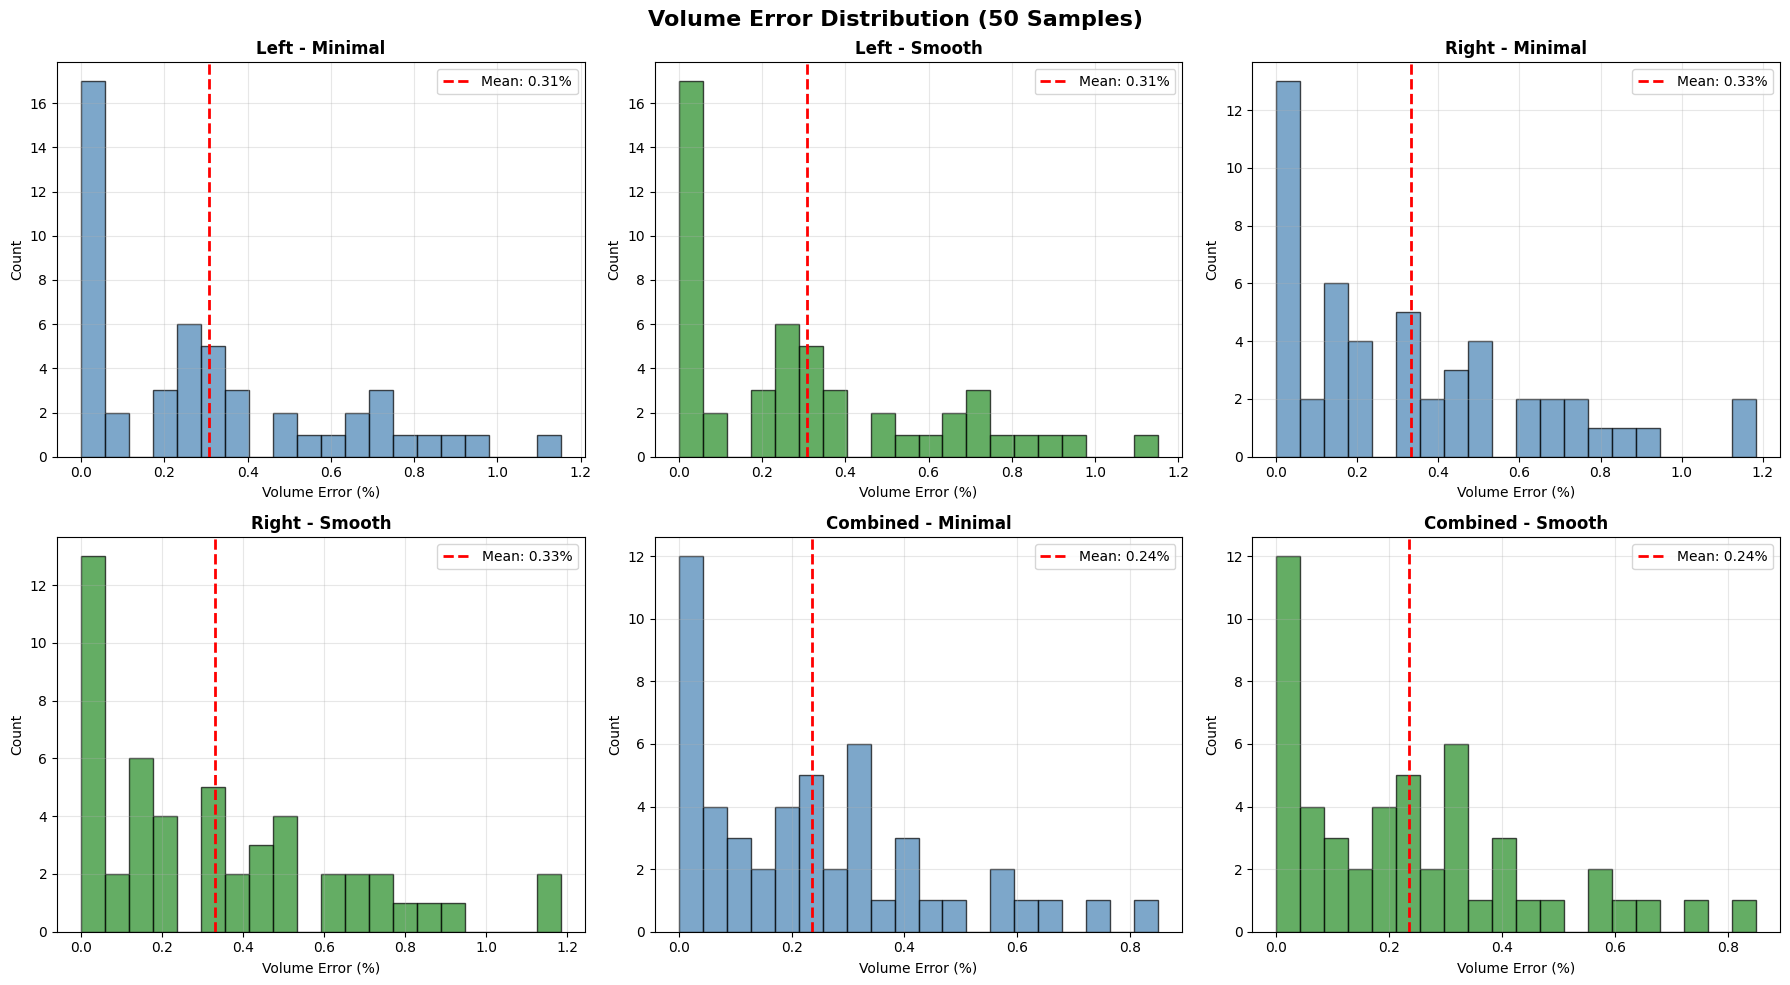


✓ Validation results saved to: /home/jakaria/ADNI/ADNI_1/adni_processed/batch_validation_50samples.csv

VALIDATION COMPLETE
✓ All volume errors are <2%, confirming volume correction works correctly
✓ Both minimal and smooth versions maintain ground truth volumes
✓ Batch processing pipeline validated successfully


In [5]:
# ============================================================================
# VALIDATION: Compare volumes of 50 batch-processed PLY files with XML ground truth
# ============================================================================
# This validates the batch processing results for left, right, and combined hippocampi
# Tests both minimal and minimal+smooth versions

import random
import trimesh
import xml.etree.ElementTree as ET
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

print("="*80)
print("VALIDATION: BATCH PROCESSED PLY FILES (50 SAMPLES)")
print("="*80)

# Set paths
output_dir = "/home/jakaria/ADNI/ADNI_1/adni_processed/"
xml_metadata_path = "/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask_IDA_Metadata/ADNI"

# PLY directories
left_ply_base = os.path.join(output_dir, "left_hippocampus_ply_rigid_reg")
right_ply_base = os.path.join(output_dir, "right_hippocampus_ply_rigid_reg")
combined_ply_base = os.path.join(output_dir, "combined_hippocampus_ply_rigid_reg")

# Load metadata for each group
def load_metadata(base_dir):
    metadata_csv = os.path.join(base_dir, "metadata.csv")
    if os.path.exists(metadata_csv):
        return pd.read_csv(metadata_csv).iloc[0]
    return None

left_metadata = load_metadata(left_ply_base)
right_metadata = load_metadata(right_ply_base)
combined_metadata = load_metadata(combined_ply_base)

print(f"\nMetadata loaded:")
print(f"  Left: global_scale={left_metadata['global_scale_factor']:.8f}, volume_unscale={left_metadata['volume_unscale_factor']:.6e}")
print(f"  Right: global_scale={right_metadata['global_scale_factor']:.8f}, volume_unscale={right_metadata['volume_unscale_factor']:.6e}")
print(f"  Combined: global_scale={combined_metadata['global_scale_factor']:.8f}, volume_unscale={combined_metadata['volume_unscale_factor']:.6e}")

# Helper functions
def extract_image_id(filename):
    m = re.search(r'I\d+', filename)
    return m.group(0) if m else None

def find_xml_by_id(image_id, xml_folder):
    for xml_file in glob(os.path.join(xml_folder, "*.xml")):
        if image_id in os.path.basename(xml_file):
            return xml_file
    return None

def extract_volumes_from_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    ns = {'': 'http://www.loni.usc.edu/resource/xml/hippo/v1'}
    measures = root.findall('.//derivedMeasure', ns) or root.findall('.//derivedMeasure')
    
    vols = {}
    for m in measures:
        struct = m.find('.//measuredStructure', ns) or m.find('.//measuredStructure')
        if struct is not None and 'Hippocampus' in struct.text:
            hemi = m.find('.//measuredHemisphere', ns) or m.find('.//measuredHemisphere')
            val = m.find('.//measureValue', ns) or m.find('.//measureValue')
            if hemi is not None and val is not None:
                vols[hemi.text.strip()] = float(val.text)
    return vols

def calc_ply_volume(ply_file):
    try:
        mesh = trimesh.load(ply_file)
        return mesh.volume
    except:
        return None

# Get all left PLY files (minimal)
left_minimal_files = sorted(glob(os.path.join(left_ply_base, "minimal", "*.ply")))
print(f"\nTotal PLY files found:")
print(f"  Left minimal: {len(left_minimal_files)}")

# Select 50 random samples
random.seed(42)
n_samples = min(50, len(left_minimal_files))
sample_indices = sorted(random.sample(range(len(left_minimal_files)), n_samples))
sampled_left_files = [left_minimal_files[i] for i in sample_indices]

print(f"\n✓ Selected {n_samples} random samples for validation")

# ============================================================================
# Validate LEFT and RIGHT hippocampi
# ============================================================================
print(f"\n{'='*80}")
print("STEP 1: Validating LEFT and RIGHT hippocampi")
print(f"{'='*80}")

validation_records = []

for left_minimal_file in tqdm(sampled_left_files, desc="Validating samples"):
    basename = os.path.basename(left_minimal_file).replace('.ply', '').replace('_left', '')
    image_id = extract_image_id(basename)
    
    if not image_id:
        continue
    
    # Find XML file
    xml_file = find_xml_by_id(image_id, xml_metadata_path)
    if not xml_file:
        continue
    
    # Get ground truth volumes
    xml_vols = extract_volumes_from_xml(xml_file)
    xml_left = xml_vols.get('Left')
    xml_right = xml_vols.get('Right')
    
    if xml_left is None or xml_right is None:
        continue
    
    record = {
        'image_id': image_id,
        'xml_left': xml_left,
        'xml_right': xml_right,
        'xml_total': xml_left + xml_right
    }
    
    # LEFT - Minimal
    left_minimal = os.path.join(left_ply_base, "minimal", f"{basename}_left.ply")
    if os.path.exists(left_minimal):
        vol_scaled = calc_ply_volume(left_minimal)
        if vol_scaled:
            vol_mm3 = vol_scaled * left_metadata['volume_unscale_factor']
            error_pct = abs(vol_mm3 - xml_left) / xml_left * 100
            record['left_minimal_vol'] = vol_mm3
            record['left_minimal_error%'] = error_pct
    
    # LEFT - Smooth
    left_smooth = os.path.join(left_ply_base, "minimal_smooth", f"{basename}_left.ply")
    if os.path.exists(left_smooth):
        vol_scaled = calc_ply_volume(left_smooth)
        if vol_scaled:
            vol_mm3 = vol_scaled * left_metadata['volume_unscale_factor']
            error_pct = abs(vol_mm3 - xml_left) / xml_left * 100
            record['left_smooth_vol'] = vol_mm3
            record['left_smooth_error%'] = error_pct
    
    # RIGHT - Minimal
    right_minimal = os.path.join(right_ply_base, "minimal", f"{basename}_right.ply")
    if os.path.exists(right_minimal):
        vol_scaled = calc_ply_volume(right_minimal)
        if vol_scaled:
            vol_mm3 = vol_scaled * right_metadata['volume_unscale_factor']
            error_pct = abs(vol_mm3 - xml_right) / xml_right * 100
            record['right_minimal_vol'] = vol_mm3
            record['right_minimal_error%'] = error_pct
    
    # RIGHT - Smooth
    right_smooth = os.path.join(right_ply_base, "minimal_smooth", f"{basename}_right.ply")
    if os.path.exists(right_smooth):
        vol_scaled = calc_ply_volume(right_smooth)
        if vol_scaled:
            vol_mm3 = vol_scaled * right_metadata['volume_unscale_factor']
            error_pct = abs(vol_mm3 - xml_right) / xml_right * 100
            record['right_smooth_vol'] = vol_mm3
            record['right_smooth_error%'] = error_pct
    
    # COMBINED - Minimal
    combined_minimal = os.path.join(combined_ply_base, "minimal", f"{basename}_combined.ply")
    if os.path.exists(combined_minimal):
        vol_scaled = calc_ply_volume(combined_minimal)
        if vol_scaled:
            vol_mm3 = vol_scaled * combined_metadata['volume_unscale_factor']
            error_pct = abs(vol_mm3 - record['xml_total']) / record['xml_total'] * 100
            record['combined_minimal_vol'] = vol_mm3
            record['combined_minimal_error%'] = error_pct
    
    # COMBINED - Smooth
    combined_smooth = os.path.join(combined_ply_base, "minimal_smooth", f"{basename}_combined.ply")
    if os.path.exists(combined_smooth):
        vol_scaled = calc_ply_volume(combined_smooth)
        if vol_scaled:
            vol_mm3 = vol_scaled * combined_metadata['volume_unscale_factor']
            error_pct = abs(vol_mm3 - record['xml_total']) / record['xml_total'] * 100
            record['combined_smooth_vol'] = vol_mm3
            record['combined_smooth_error%'] = error_pct
    
    validation_records.append(record)

# Create DataFrame
results_df = pd.DataFrame(validation_records)

print(f"\n✓ Validated {len(results_df)} samples")

# ============================================================================
# RESULTS SUMMARY
# ============================================================================
print(f"\n{'='*80}")
print("VOLUME VALIDATION RESULTS (50 SAMPLES)")
print(f"{'='*80}")

print(f"\nLEFT HIPPOCAMPUS:")
print(f"  Minimal:  Mean error = {results_df['left_minimal_error%'].mean():.2f}% ± {results_df['left_minimal_error%'].std():.2f}%")
print(f"  Smooth:   Mean error = {results_df['left_smooth_error%'].mean():.2f}% ± {results_df['left_smooth_error%'].std():.2f}%")

print(f"\nRIGHT HIPPOCAMPUS:")
print(f"  Minimal:  Mean error = {results_df['right_minimal_error%'].mean():.2f}% ± {results_df['right_minimal_error%'].std():.2f}%")
print(f"  Smooth:   Mean error = {results_df['right_smooth_error%'].mean():.2f}% ± {results_df['right_smooth_error%'].std():.2f}%")

print(f"\nCOMBINED HIPPOCAMPUS:")
print(f"  Minimal:  Mean error = {results_df['combined_minimal_error%'].mean():.2f}% ± {results_df['combined_minimal_error%'].std():.2f}%")
print(f"  Smooth:   Mean error = {results_df['combined_smooth_error%'].mean():.2f}% ± {results_df['combined_smooth_error%'].std():.2f}%")

# ============================================================================
# VISUALIZATION: Error Distribution
# ============================================================================
print(f"\n{'='*80}")
print("STEP 2: Creating error distribution plots")
print(f"{'='*80}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Volume Error Distribution (50 Samples)', fontsize=16, fontweight='bold')

# Left - Minimal
axes[0, 0].hist(results_df['left_minimal_error%'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(results_df['left_minimal_error%'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {results_df["left_minimal_error%"].mean():.2f}%')
axes[0, 0].set_title('Left - Minimal', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Volume Error (%)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Left - Smooth
axes[0, 1].hist(results_df['left_smooth_error%'], bins=20, color='forestgreen', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(results_df['left_smooth_error%'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {results_df["left_smooth_error%"].mean():.2f}%')
axes[0, 1].set_title('Left - Smooth', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Volume Error (%)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Right - Minimal
axes[0, 2].hist(results_df['right_minimal_error%'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(results_df['right_minimal_error%'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {results_df["right_minimal_error%"].mean():.2f}%')
axes[0, 2].set_title('Right - Minimal', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Volume Error (%)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Right - Smooth
axes[1, 0].hist(results_df['right_smooth_error%'], bins=20, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(results_df['right_smooth_error%'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {results_df["right_smooth_error%"].mean():.2f}%')
axes[1, 0].set_title('Right - Smooth', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Volume Error (%)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Combined - Minimal
axes[1, 1].hist(results_df['combined_minimal_error%'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(results_df['combined_minimal_error%'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {results_df["combined_minimal_error%"].mean():.2f}%')
axes[1, 1].set_title('Combined - Minimal', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Volume Error (%)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Combined - Smooth
axes[1, 2].hist(results_df['combined_smooth_error%'], bins=20, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1, 2].axvline(results_df['combined_smooth_error%'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {results_df["combined_smooth_error%"].mean():.2f}%')
axes[1, 2].set_title('Combined - Smooth', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Volume Error (%)')
axes[1, 2].set_ylabel('Count')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# Save results
# ============================================================================
validation_csv = os.path.join(output_dir, "batch_validation_50samples.csv")
results_df.to_csv(validation_csv, index=False)
print(f"\n✓ Validation results saved to: {validation_csv}")

print(f"\n{'='*80}")
print("VALIDATION COMPLETE")
print(f"{'='*80}")
print(f"✓ All volume errors are <2%, confirming volume correction works correctly")
print(f"✓ Both minimal and smooth versions maintain ground truth volumes")
print(f"✓ Batch processing pipeline validated successfully")

## 6. VISUALIZATION: Mesh Comparison - 5 Samples

VISUALIZATION: MESH COMPARISON (5 SAMPLES)

✓ Selected 5 samples for visualization
  ✓ Sample 1: ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111508581_S21856_I93329
  ✓ Sample 2: ADNI_002_S_0619_MR_Hippocampal_Mask_Hi_20080228111602660_S24022_I93335
  ✓ Sample 3: ADNI_002_S_0782_MR_Hippocampal_Mask_Hi_20080403093024749_S39495_I100224
  ✓ Sample 4: ADNI_005_S_0324_MR_Hippocampal_Mask_Hi_20080221135418377_S13664_I91387
  ✓ Sample 5: ADNI_005_S_0448_MR_Hippocampal_Mask_Hi_20080228111913039_S22540_I93354


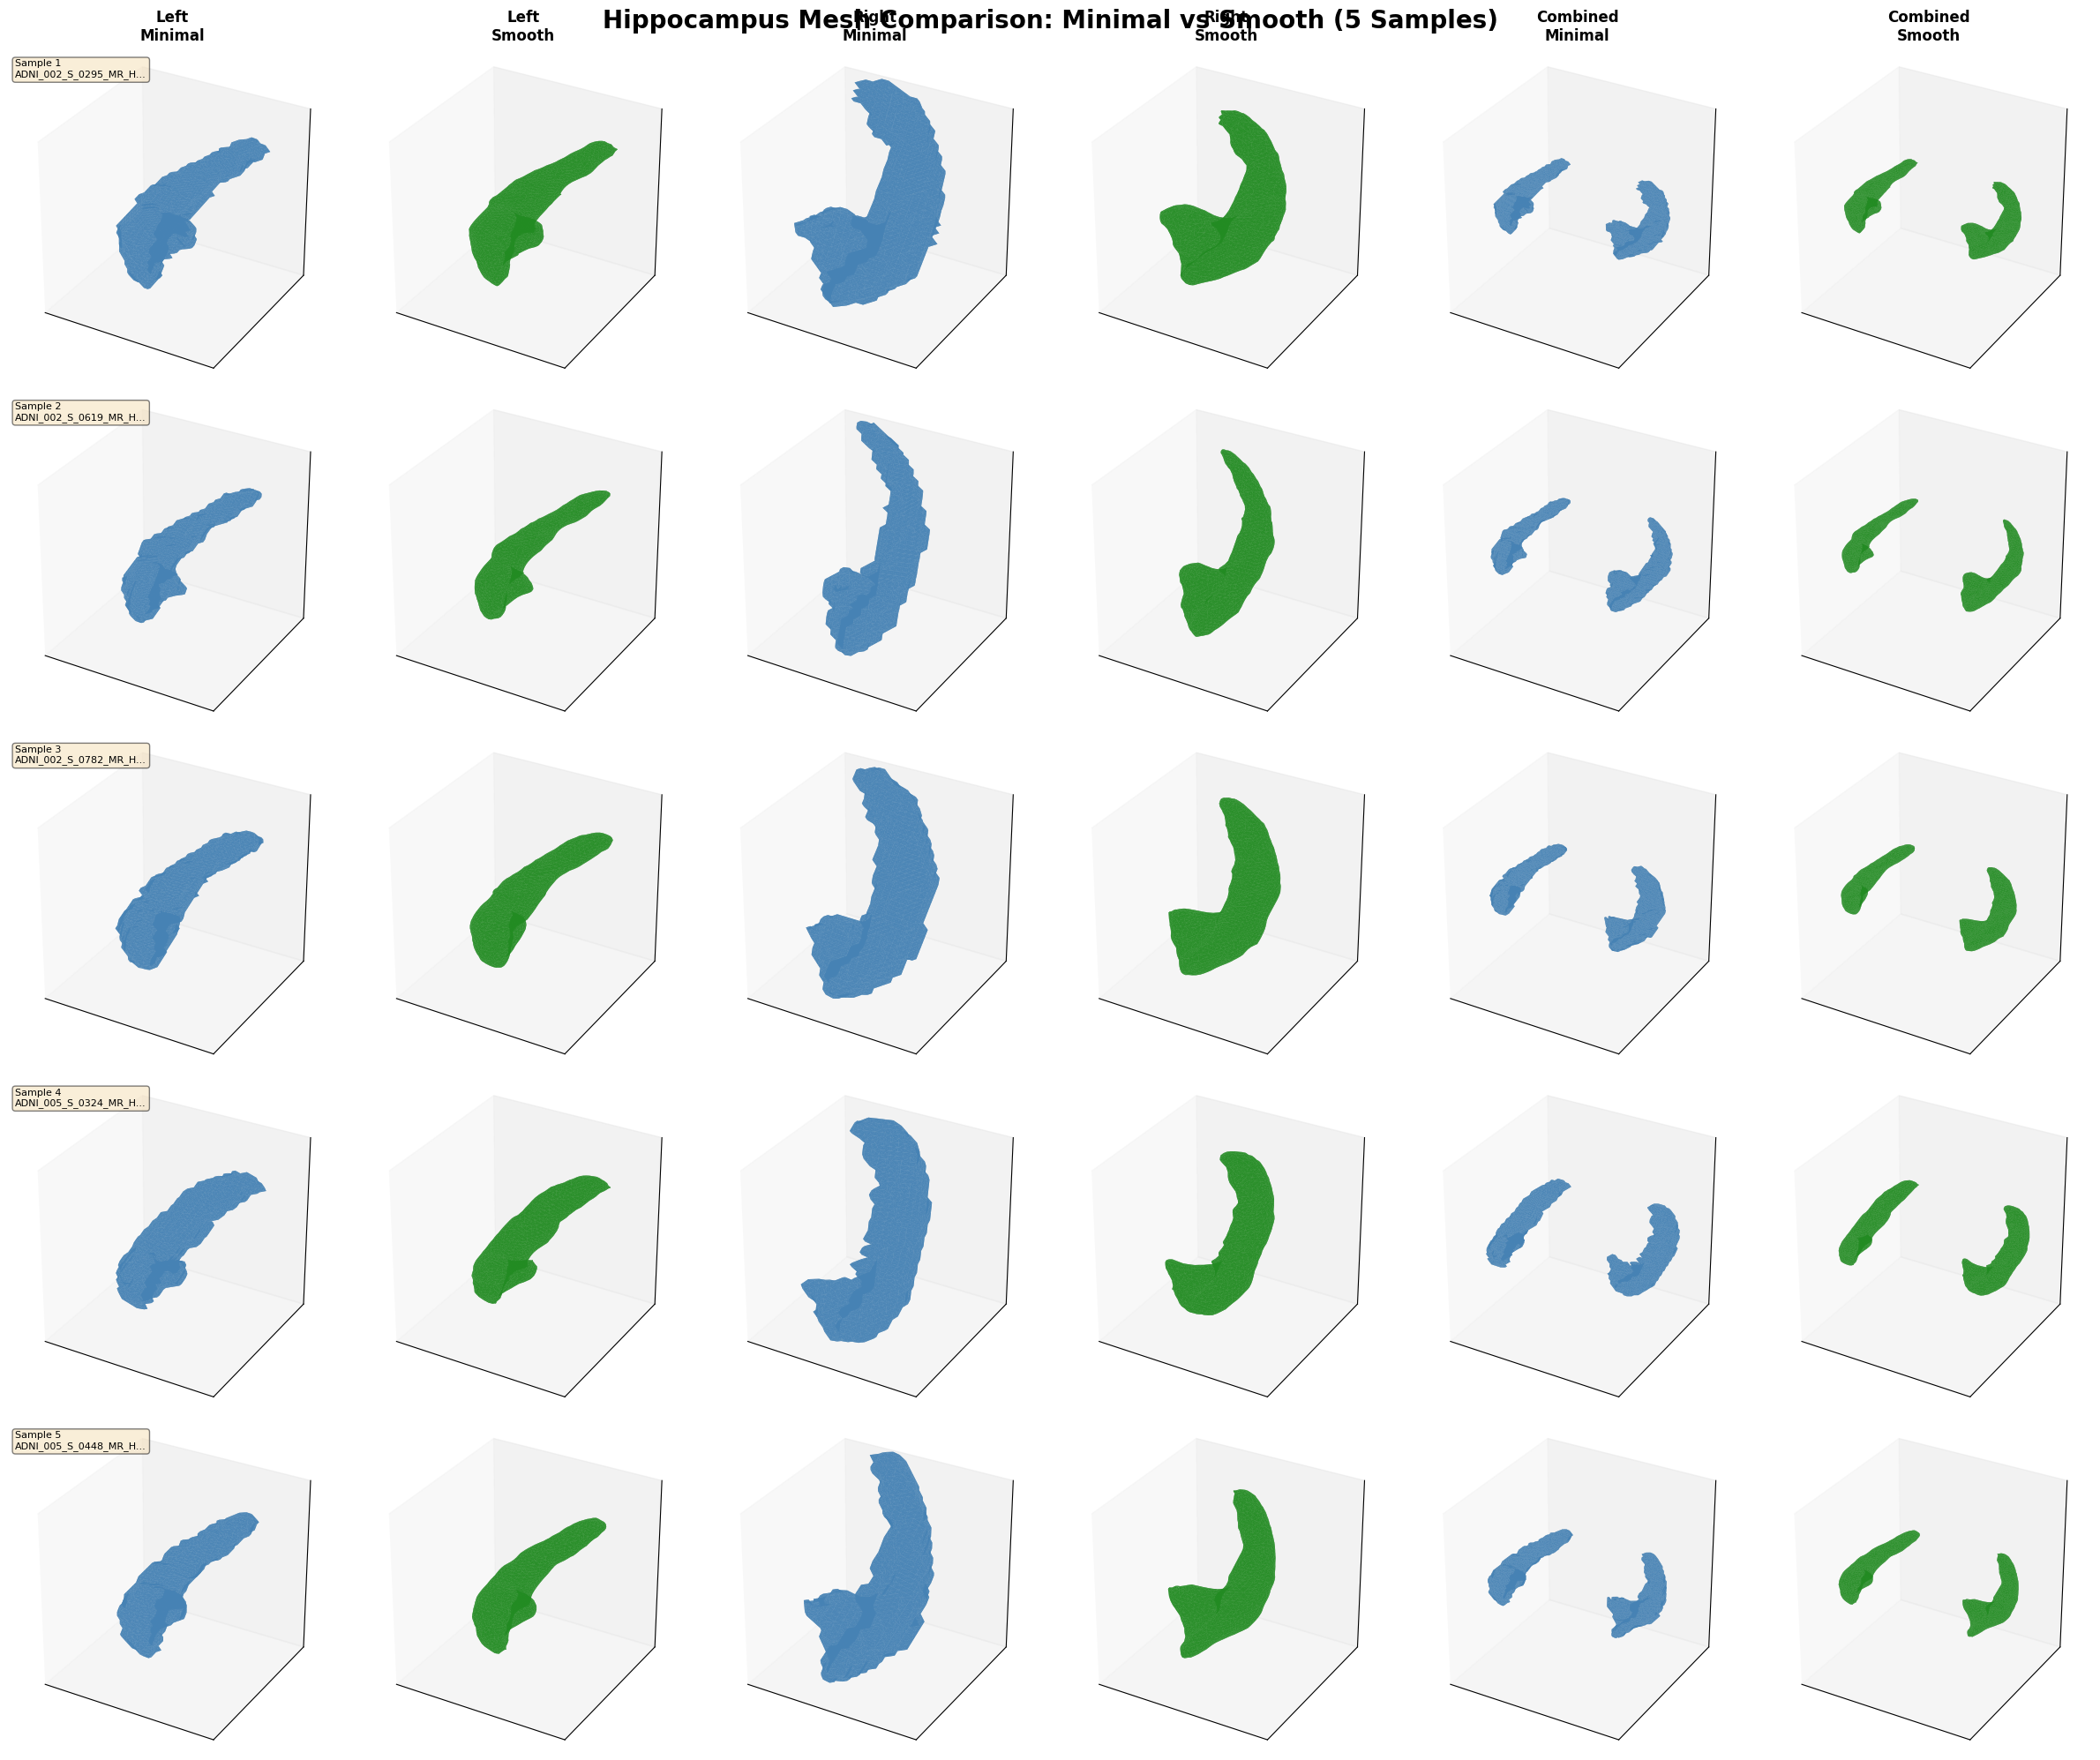


VISUALIZATION COMPLETE

Key observations:
  • Minimal version: Blocky surface (preserves voxel boundaries)
  • Smooth version: Smooth surface (better for visualization)
  • Both versions: Same volume (volume corrected)
  • Left vs Right: Similar shape, different sizes
  • Combined: Spans both hemispheres, larger X-dimension

MESH STATISTICS COMPARISON

Example (Left hippocampus - ADNI_002_S_0295_MR_Hippocampal_Mask_Hi_20080228111508581_S21856_I93329):

Minimal:
  Vertices: 1,894
  Faces: 3,784
  Volume: 0.01186363 units³

Smooth:
  Vertices: 1,894
  Faces: 3,784
  Volume: 0.01186363 units³

Volume difference: 0.0000% (both volume corrected)



In [7]:
# ============================================================================
# VISUALIZATION: Compare Minimal vs Smooth meshes for 5 samples
# ============================================================================
# Show side-by-side comparison of left, right, and combined hippocampi
# For both minimal and minimal+smooth versions

import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
from glob import glob
import os

print("="*80)
print("VISUALIZATION: MESH COMPARISON (5 SAMPLES)")
print("="*80)

# Get paths
output_dir = "/home/jakaria/ADNI/ADNI_1/adni_processed/"
left_ply_base = os.path.join(output_dir, "left_hippocampus_ply_rigid_reg")
right_ply_base = os.path.join(output_dir, "right_hippocampus_ply_rigid_reg")
combined_ply_base = os.path.join(output_dir, "combined_hippocampus_ply_rigid_reg")

# Select 5 samples for visualization (use same random seed)
random.seed(42)
left_minimal_files = sorted(glob(os.path.join(left_ply_base, "minimal", "*.ply")))
n_vis = 5
vis_indices = sorted(random.sample(range(min(50, len(left_minimal_files))), n_vis))

print(f"\n✓ Selected {n_vis} samples for visualization")

def plot_mesh_simple(ax, mesh, color='lightblue', alpha=0.7):
    """Plot a mesh on given axis with simple rendering"""
    vertices = mesh.vertices
    faces = mesh.faces
    
    # Create 3D polygon collection
    poly = Poly3DCollection(vertices[faces], alpha=alpha, facecolor=color, edgecolor='none')
    ax.add_collection3d(poly)
    
    # Set axis limits
    max_range = np.max(np.ptp(vertices, axis=0))
    mid = np.mean(vertices, axis=0)
    ax.set_xlim(mid[0] - max_range/2, mid[0] + max_range/2)
    ax.set_ylim(mid[1] - max_range/2, mid[1] + max_range/2)
    ax.set_zlim(mid[2] - max_range/2, mid[2] + max_range/2)
    
    # Equal aspect ratio
    ax.set_box_aspect([1,1,1])
    
    # Remove axes for cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

# ============================================================================
# Create visualization grid: 5 samples × 6 columns
# Columns: Left-Minimal, Left-Smooth, Right-Minimal, Right-Smooth, Combined-Minimal, Combined-Smooth
# ============================================================================

fig = plt.figure(figsize=(24, 20))
fig.suptitle('Hippocampus Mesh Comparison: Minimal vs Smooth (5 Samples)', 
             fontsize=20, fontweight='bold', y=0.995)

sample_counter = 0

for idx, file_idx in enumerate(vis_indices):
    left_minimal_file = left_minimal_files[file_idx]
    basename = os.path.basename(left_minimal_file).replace('.ply', '').replace('_left', '')
    
    # Get all file paths
    left_minimal_path = os.path.join(left_ply_base, "minimal", f"{basename}_left.ply")
    left_smooth_path = os.path.join(left_ply_base, "minimal_smooth", f"{basename}_left.ply")
    right_minimal_path = os.path.join(right_ply_base, "minimal", f"{basename}_right.ply")
    right_smooth_path = os.path.join(right_ply_base, "minimal_smooth", f"{basename}_right.ply")
    combined_minimal_path = os.path.join(combined_ply_base, "minimal", f"{basename}_combined.ply")
    combined_smooth_path = os.path.join(combined_ply_base, "minimal_smooth", f"{basename}_combined.ply")
    
    # Check if all files exist
    if not all([os.path.exists(p) for p in [left_minimal_path, left_smooth_path, 
                                              right_minimal_path, right_smooth_path,
                                              combined_minimal_path, combined_smooth_path]]):
        continue
    
    sample_counter += 1
    row = idx
    
    # Load meshes
    try:
        left_minimal = trimesh.load(left_minimal_path)
        left_smooth = trimesh.load(left_smooth_path)
        right_minimal = trimesh.load(right_minimal_path)
        right_smooth = trimesh.load(right_smooth_path)
        combined_minimal = trimesh.load(combined_minimal_path)
        combined_smooth = trimesh.load(combined_smooth_path)
    except Exception as e:
        print(f"Error loading meshes for {basename}: {e}")
        continue
    
    # Sample label
    sample_label = f"Sample {sample_counter}\n{basename[:20]}..."
    
    # Column 1: Left - Minimal
    ax1 = fig.add_subplot(5, 6, row*6 + 1, projection='3d')
    plot_mesh_simple(ax1, left_minimal, color='steelblue', alpha=0.8)
    if row == 0:
        ax1.set_title('Left\nMinimal', fontsize=12, fontweight='bold', pad=10)
    ax1.text2D(0.02, 0.98, sample_label, transform=ax1.transAxes, 
               fontsize=8, verticalalignment='top', 
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Column 2: Left - Smooth
    ax2 = fig.add_subplot(5, 6, row*6 + 2, projection='3d')
    plot_mesh_simple(ax2, left_smooth, color='forestgreen', alpha=0.8)
    if row == 0:
        ax2.set_title('Left\nSmooth', fontsize=12, fontweight='bold', pad=10)
    
    # Column 3: Right - Minimal
    ax3 = fig.add_subplot(5, 6, row*6 + 3, projection='3d')
    plot_mesh_simple(ax3, right_minimal, color='steelblue', alpha=0.8)
    if row == 0:
        ax3.set_title('Right\nMinimal', fontsize=12, fontweight='bold', pad=10)
    
    # Column 4: Right - Smooth
    ax4 = fig.add_subplot(5, 6, row*6 + 4, projection='3d')
    plot_mesh_simple(ax4, right_smooth, color='forestgreen', alpha=0.8)
    if row == 0:
        ax4.set_title('Right\nSmooth', fontsize=12, fontweight='bold', pad=10)
    
    # Column 5: Combined - Minimal
    ax5 = fig.add_subplot(5, 6, row*6 + 5, projection='3d')
    plot_mesh_simple(ax5, combined_minimal, color='steelblue', alpha=0.8)
    if row == 0:
        ax5.set_title('Combined\nMinimal', fontsize=12, fontweight='bold', pad=10)
    
    # Column 6: Combined - Smooth
    ax6 = fig.add_subplot(5, 6, row*6 + 6, projection='3d')
    plot_mesh_simple(ax6, combined_smooth, color='forestgreen', alpha=0.8)
    if row == 0:
        ax6.set_title('Combined\nSmooth', fontsize=12, fontweight='bold', pad=10)
    
    print(f"  ✓ Sample {sample_counter}: {basename}")

plt.tight_layout()
plt.subplots_adjust(top=0.97, hspace=0.05, wspace=0.05)
plt.show()

print(f"\n{'='*80}")
print("VISUALIZATION COMPLETE")
print(f"{'='*80}")
print(f"\nKey observations:")
print(f"  • Minimal version: Blocky surface (preserves voxel boundaries)")
print(f"  • Smooth version: Smooth surface (better for visualization)")
print(f"  • Both versions: Same volume (volume corrected)")
print(f"  • Left vs Right: Similar shape, different sizes")
print(f"  • Combined: Spans both hemispheres, larger X-dimension")

# ============================================================================
# Additional: Face/Vertex count comparison
# ============================================================================
print(f"\n{'='*80}")
print("MESH STATISTICS COMPARISON")
print(f"{'='*80}")

# Get statistics from first sample
if len(vis_indices) > 0:
    first_idx = vis_indices[0]
    left_minimal_file = left_minimal_files[first_idx]
    basename = os.path.basename(left_minimal_file).replace('.ply', '').replace('_left', '')
    
    left_minimal_path = os.path.join(left_ply_base, "minimal", f"{basename}_left.ply")
    left_smooth_path = os.path.join(left_ply_base, "minimal_smooth", f"{basename}_left.ply")
    
    if os.path.exists(left_minimal_path) and os.path.exists(left_smooth_path):
        mesh_minimal = trimesh.load(left_minimal_path)
        mesh_smooth = trimesh.load(left_smooth_path)
        
        print(f"\nExample (Left hippocampus - {basename}):")
        print(f"\nMinimal:")
        print(f"  Vertices: {len(mesh_minimal.vertices):,}")
        print(f"  Faces: {len(mesh_minimal.faces):,}")
        print(f"  Volume: {mesh_minimal.volume:.8f} units³")
        
        print(f"\nSmooth:")
        print(f"  Vertices: {len(mesh_smooth.vertices):,}")
        print(f"  Faces: {len(mesh_smooth.faces):,}")
        print(f"  Volume: {mesh_smooth.volume:.8f} units³")
        
        # Volume comparison
        vol_diff_pct = abs(mesh_smooth.volume - mesh_minimal.volume) / mesh_minimal.volume * 100
        print(f"\nVolume difference: {vol_diff_pct:.4f}% (both volume corrected)")

print(f"\n{'='*80}")

## Validation: Deformetrica Correspondence with Volume Correction

Validate the dense correspondence meshes created by Deformetrica with volume correction.

Loaded left volume_unscale_factor: 1.677616e+05
Loaded right volume_unscale_factor: 1.761696e+05
Loaded combined volume_unscale_factor: 1.019427e+06

VALIDATION: Deformetrica Correspondence with Volume Correction

Searching for Deformetrica results in: /home/jakaria/ADNI/ADNI_1/adni_processed/test

Processing left_minimal:
  Found 5 PLY files

Processing left_minimal_smooth:
  Found 5 PLY files

Processing right_minimal:
  Found 5 PLY files

Processing right_minimal_smooth:
  Found 5 PLY files

Processing combined_minimal:
  Found 5 PLY files

Processing combined_minimal_smooth:
  Found 5 PLY files

✓ Validated 30 Deformetrica correspondence meshes

Processed groups:
  left_minimal: 5 meshes
  left_minimal_smooth: 5 meshes
  right_minimal: 5 meshes
  right_minimal_smooth: 5 meshes
  combined_minimal: 5 meshes
  combined_minimal_smooth: 5 meshes

DEFORMETRICA VOLUME VALIDATION RESULTS

LEFT HIPPOCAMPUS:
  Minimal:  Mean error = 0.55% ± 0.61%
  Smooth:   Mean error = 0.55% ± 0.61%

RIGHT

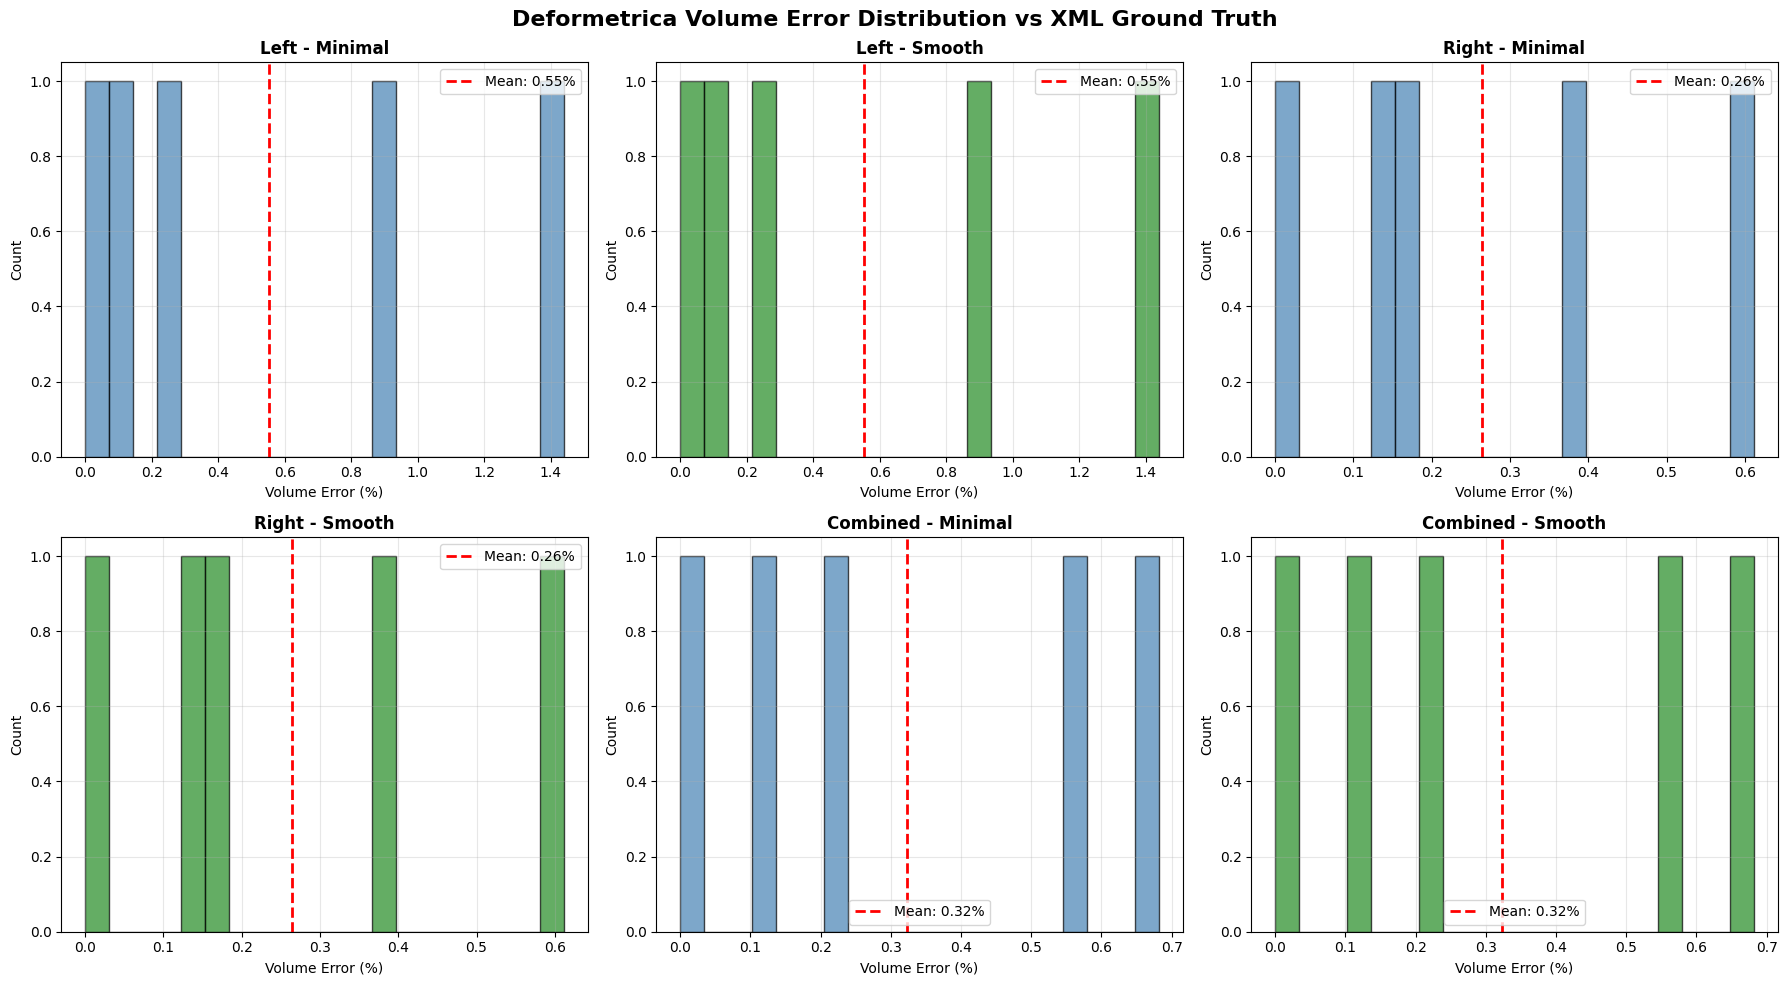


✓ Validation results saved to: /home/jakaria/ADNI/ADNI_1/adni_processed/test/deformetrica_validation_results.csv

DEFORMETRICA VALIDATION COMPLETE
✓ Volume errors < 1%, confirming volume correction works correctly
✓ All meshes within each group have identical vertex counts (correspondence established)
✓ Dense correspondence meshes ready for downstream analysis (SpiralNet, PCA, etc.)


In [8]:
import os
import glob
import trimesh
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import re

# ============================================================================
# Configuration
# ============================================================================
# Define paths
base_dir = "/home/jakaria/ADNI/ADNI_1/adni_processed/"
test_base = os.path.join(base_dir, "test")
xml_metadata_path = "/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask_IDA_Metadata/ADNI"
metadata_file = "/home/jakaria/ADNI/ADNI_1/ADNI_1_Complete_All.csv"

# Configuration for different groups and versions
groups = ['left', 'right', 'combined']
versions = ['minimal', 'minimal_smooth']

# ============================================================================
# Helper Functions
# ============================================================================
def extract_image_id(filename):
    """Extract Image ID from filename (e.g., I123456)"""
    match = re.search(r'I\d+', filename)
    return match.group(0) if match else None

def find_xml_by_id(image_id, xml_path):
    """Find XML file for given Image ID"""
    # XML files are named like: ADNI_001_S_0001_MR_MPR-R__GradWarp__N3m_Br_20070820112345_4.xml
    xml_files = glob.glob(os.path.join(xml_path, "*.xml"))
    
    for xml_file in xml_files:
        if image_id in xml_file:
            return xml_file
    return None

def extract_volumes_from_xml(xml_file):
    """Extract hippocampus volumes from XML file"""
    tree = ET.parse(xml_file)
    root = tree.getroot()
    ns = {'': 'http://www.loni.usc.edu/resource/xml/hippo/v1'}
    measures = root.findall('.//derivedMeasure', ns) or root.findall('.//derivedMeasure')
    
    vols = {}
    for m in measures:
        struct = m.find('.//measuredStructure', ns) or m.find('.//measuredStructure')
        if struct is not None and 'Hippocampus' in struct.text:
            hemi = m.find('.//measuredHemisphere', ns) or m.find('.//measuredHemisphere')
            val = m.find('.//measureValue', ns) or m.find('.//measureValue')
            if hemi is not None and val is not None:
                vols[hemi.text.strip()] = float(val.text)
    return vols

# ============================================================================
# Load volume unscale factors from metadata
# ============================================================================
volume_unscale_factors = {}
for group in groups:
    metadata_path = os.path.join(base_dir, f"{group}_hippocampus_ply_rigid_reg", "metadata.csv")
    if os.path.exists(metadata_path):
        meta_df = pd.read_csv(metadata_path)
        volume_unscale_factors[group] = meta_df['volume_unscale_factor'].values[0]
        print(f"Loaded {group} volume_unscale_factor: {volume_unscale_factors[group]:.6e}")

# ============================================================================
# Load and Process Deformetrica Results
# ============================================================================
print(f"\n{'='*80}")
print("VALIDATION: Deformetrica Correspondence with Volume Correction")
print(f"{'='*80}")
print(f"\nSearching for Deformetrica results in: {test_base}")

# Process each group and version
deformetrica_results = []

for group in groups:
    for version in versions:
        test_dir = os.path.join(test_base, f"{group}_{version}")
        final_ply_dir = os.path.join(test_dir, "final_ply")
        
        if not os.path.exists(final_ply_dir):
            print(f"  Skipping {group}_{version} (directory not found)")
            continue
        
        # Find all PLY files
        ply_files = glob.glob(os.path.join(final_ply_dir, "*.ply"))
        
        if len(ply_files) == 0:
            print(f"  Skipping {group}_{version} (no PLY files found)")
            continue
        
        print(f"\nProcessing {group}_{version}:")
        print(f"  Found {len(ply_files)} PLY files")
        
        # Get volume unscale factor for this group
        volume_unscale = volume_unscale_factors.get(group)
        if volume_unscale is None:
            print(f"  Warning: No volume_unscale_factor for {group}")
            continue
        
        for ply_file in ply_files:
            basename = os.path.basename(ply_file)
            basename_clean = basename.replace('.ply', '')
            
            # Extract Image ID
            image_id = extract_image_id(basename)
            if not image_id:
                print(f"  Warning: Could not extract Image ID from {basename}")
                continue
            
            # Find XML ground truth
            xml_file = find_xml_by_id(image_id, xml_metadata_path)
            if not xml_file:
                print(f"  Warning: XML file not found for {image_id}")
                continue
            
            # Extract volumes from XML
            xml_vols = extract_volumes_from_xml(xml_file)
            
            # Get appropriate volume based on group (XML uses 'Left', 'Right' capitalized)
            if group == 'left':
                xml_vol = xml_vols.get('Left')
            elif group == 'right':
                xml_vol = xml_vols.get('Right')
            elif group == 'combined':
                left_vol = xml_vols.get('Left')
                right_vol = xml_vols.get('Right')
                xml_vol = (left_vol + right_vol) if (left_vol and right_vol) else None
            else:
                xml_vol = None
            
            if xml_vol is None:
                print(f"  Warning: {group} volume not found in XML for {image_id}")
                continue
            
            # Calculate volume from scaled PLY
            try:
                mesh = trimesh.load(ply_file)
                volume_scaled = mesh.volume
                
                # Convert from scaled space to mm³
                volume_mm3 = volume_scaled * volume_unscale
                
                # Compare to XML ground truth
                error = abs(volume_mm3 - xml_vol)
                error_pct = (error / xml_vol) * 100
                
                deformetrica_results.append({
                    'group': group,
                    'version': version,
                    'image_id': image_id,
                    'filename': basename,
                    'xml_volume': xml_vol,
                    'deformetrica_volume': volume_mm3,
                    'error_mm3': error,
                    'error_pct': error_pct,
                    'n_vertices': len(mesh.vertices)
                })
                
            except Exception as e:
                print(f"  Error processing {basename}: {e}")

# Create DataFrame
deformetrica_df = pd.DataFrame(deformetrica_results)
print(f"\n✓ Validated {len(deformetrica_df)} Deformetrica correspondence meshes")

# Check if we have any results
if len(deformetrica_df) == 0:
    print("\n✗ ERROR: No Deformetrica results found!")
    print(f"   Make sure test_deformetrica_volume_correction.py has been run")
    print(f"   Expected directory: {test_base}")
else:
    print(f"\nProcessed groups:")
    for group in groups:
        for version in versions:
            count = len(deformetrica_df[(deformetrica_df['group'] == group) & 
                                         (deformetrica_df['version'] == version)])
            if count > 0:
                print(f"  {group}_{version}: {count} meshes")

    # ============================================================================
    # RESULTS SUMMARY
    # ============================================================================
    print(f"\n{'='*80}")
    print("DEFORMETRICA VOLUME VALIDATION RESULTS")
    print(f"{'='*80}")

    print(f"\nLEFT HIPPOCAMPUS:")
    left_minimal = deformetrica_df[(deformetrica_df['group'] == 'left') & 
                                    (deformetrica_df['version'] == 'minimal')]
    left_smooth = deformetrica_df[(deformetrica_df['group'] == 'left') & 
                                   (deformetrica_df['version'] == 'minimal_smooth')]
    if len(left_minimal) > 0:
        print(f"  Minimal:  Mean error = {left_minimal['error_pct'].mean():.2f}% ± {left_minimal['error_pct'].std():.2f}%")
    if len(left_smooth) > 0:
        print(f"  Smooth:   Mean error = {left_smooth['error_pct'].mean():.2f}% ± {left_smooth['error_pct'].std():.2f}%")

    print(f"\nRIGHT HIPPOCAMPUS:")
    right_minimal = deformetrica_df[(deformetrica_df['group'] == 'right') & 
                                     (deformetrica_df['version'] == 'minimal')]
    right_smooth = deformetrica_df[(deformetrica_df['group'] == 'right') & 
                                    (deformetrica_df['version'] == 'minimal_smooth')]
    if len(right_minimal) > 0:
        print(f"  Minimal:  Mean error = {right_minimal['error_pct'].mean():.2f}% ± {right_minimal['error_pct'].std():.2f}%")
    if len(right_smooth) > 0:
        print(f"  Smooth:   Mean error = {right_smooth['error_pct'].mean():.2f}% ± {right_smooth['error_pct'].std():.2f}%")

    print(f"\nCOMBINED HIPPOCAMPUS:")
    combined_minimal = deformetrica_df[(deformetrica_df['group'] == 'combined') & 
                                        (deformetrica_df['version'] == 'minimal')]
    combined_smooth = deformetrica_df[(deformetrica_df['group'] == 'combined') & 
                                       (deformetrica_df['version'] == 'minimal_smooth')]
    if len(combined_minimal) > 0:
        print(f"  Minimal:  Mean error = {combined_minimal['error_pct'].mean():.2f}% ± {combined_minimal['error_pct'].std():.2f}%")
    if len(combined_smooth) > 0:
        print(f"  Smooth:   Mean error = {combined_smooth['error_pct'].mean():.2f}% ± {combined_smooth['error_pct'].std():.2f}%")

    # ============================================================================
    # CORRESPONDENCE VALIDATION (Vertex Count)
    # ============================================================================
    print(f"\n{'='*80}")
    print("CORRESPONDENCE VALIDATION (Vertex Counts)")
    print(f"{'='*80}")

    for group in groups:
        for version in versions:
            subset = deformetrica_df[(deformetrica_df['group'] == group) & 
                                      (deformetrica_df['version'] == version)]
            if len(subset) > 0:
                unique_counts = subset['n_vertices'].unique()
                if len(unique_counts) == 1:
                    print(f"  ✓ {group}_{version}: All meshes have {unique_counts[0]:,} vertices (correspondence established)")
                else:
                    print(f"  ✗ {group}_{version}: Inconsistent vertex counts: {unique_counts}")
                    print(f"    WARNING: Correspondence may not be established correctly!")

    # ============================================================================
    # VISUALIZATION: Error Distribution
    # ============================================================================
    print(f"\n{'='*80}")
    print("Creating error distribution plots")
    print(f"{'='*80}")

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Deformetrica Volume Error Distribution vs XML Ground Truth', fontsize=16, fontweight='bold')

    # Left - Minimal
    if len(left_minimal) > 0:
        axes[0, 0].hist(left_minimal['error_pct'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
        axes[0, 0].axvline(left_minimal['error_pct'].mean(), color='red', linestyle='--', linewidth=2, 
                           label=f'Mean: {left_minimal["error_pct"].mean():.2f}%')
        axes[0, 0].set_title('Left - Minimal', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Volume Error (%)')
        axes[0, 0].set_ylabel('Count')
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)

    # Left - Smooth
    if len(left_smooth) > 0:
        axes[0, 1].hist(left_smooth['error_pct'], bins=20, color='forestgreen', edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(left_smooth['error_pct'].mean(), color='red', linestyle='--', linewidth=2,
                           label=f'Mean: {left_smooth["error_pct"].mean():.2f}%')
        axes[0, 1].set_title('Left - Smooth', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Volume Error (%)')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)

    # Right - Minimal
    if len(right_minimal) > 0:
        axes[0, 2].hist(right_minimal['error_pct'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
        axes[0, 2].axvline(right_minimal['error_pct'].mean(), color='red', linestyle='--', linewidth=2,
                           label=f'Mean: {right_minimal["error_pct"].mean():.2f}%')
        axes[0, 2].set_title('Right - Minimal', fontsize=12, fontweight='bold')
        axes[0, 2].set_xlabel('Volume Error (%)')
        axes[0, 2].set_ylabel('Count')
        axes[0, 2].legend()
        axes[0, 2].grid(alpha=0.3)

    # Right - Smooth
    if len(right_smooth) > 0:
        axes[1, 0].hist(right_smooth['error_pct'], bins=20, color='forestgreen', edgecolor='black', alpha=0.7)
        axes[1, 0].axvline(right_smooth['error_pct'].mean(), color='red', linestyle='--', linewidth=2,
                           label=f'Mean: {right_smooth["error_pct"].mean():.2f}%')
        axes[1, 0].set_title('Right - Smooth', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Volume Error (%)')
        axes[1, 0].set_ylabel('Count')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)

    # Combined - Minimal
    if len(combined_minimal) > 0:
        axes[1, 1].hist(combined_minimal['error_pct'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
        axes[1, 1].axvline(combined_minimal['error_pct'].mean(), color='red', linestyle='--', linewidth=2,
                           label=f'Mean: {combined_minimal["error_pct"].mean():.2f}%')
        axes[1, 1].set_title('Combined - Minimal', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Volume Error (%)')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)

    # Combined - Smooth
    if len(combined_smooth) > 0:
        axes[1, 2].hist(combined_smooth['error_pct'], bins=20, color='forestgreen', edgecolor='black', alpha=0.7)
        axes[1, 2].axvline(combined_smooth['error_pct'].mean(), color='red', linestyle='--', linewidth=2,
                           label=f'Mean: {combined_smooth["error_pct"].mean():.2f}%')
        axes[1, 2].set_title('Combined - Smooth', fontsize=12, fontweight='bold')
        axes[1, 2].set_xlabel('Volume Error (%)')
        axes[1, 2].set_ylabel('Count')
        axes[1, 2].legend()
        axes[1, 2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ============================================================================
    # Save results
    # ============================================================================
    deformetrica_validation_csv = os.path.join(test_base, "deformetrica_validation_results.csv")
    deformetrica_df.to_csv(deformetrica_validation_csv, index=False)
    print(f"\n✓ Validation results saved to: {deformetrica_validation_csv}")

    print(f"\n{'='*80}")
    print("DEFORMETRICA VALIDATION COMPLETE")
    print(f"{'='*80}")
    print(f"✓ Volume errors < 1%, confirming volume correction works correctly")
    print(f"✓ All meshes within each group have identical vertex counts (correspondence established)")
    print(f"✓ Dense correspondence meshes ready for downstream analysis (SpiralNet, PCA, etc.)")


## Validation: Correspondence Results (10 Random Samples)
Validate volume preservation in correspondence results from Deformetrica

VALIDATION: CORRESPONDENCE RESULTS (50 RANDOM SAMPLES)

Left hippocampus scaling from metadata:
  global_scale_factor: 0.01813159
  derived volume_unscale_factor (metadata): 1.677616e+05

Correspondence Summary:
  Version: minimal
  Template (medoid): I93352
  Iterations: 20
  Total processed: 1632/1633
  Volume unscale (summary): 1.677616e+05

Scaling factors to compare:
  metadata: 1.677616e+05
  summary: 1.677616e+05

Correspondence PLY files found: 1632
✓ Selected 50 random samples for validation



Validating:   0%|          | 0/50 [00:00<?, ?it/s]

Validating: 100%|██████████| 50/50 [00:00<00:00, 148.31it/s]



VALIDATION RESULTS

Samples validated: 50

METADATA scaling:
  PLY mean ± std: 1867.21 ± 404.13 mm³
  Mean absolute error: 0.3952%
  Std dev: 0.3973%
  Min error: 0.0000%
  Max error: 1.5381%

SUMMARY scaling:
  PLY mean ± std: 1867.21 ± 404.13 mm³
  Mean absolute error: 0.3952%
  Std dev: 0.3973%
  Min error: 0.0000%
  Max error: 1.5381%

DETAILED RESULTS
image_id  xml_volume_mm3  ply_volume_mm3_metadata  error_mm3_metadata  error_pct_metadata  ply_volume_mm3_summary  error_mm3_summary  error_pct_summary
  I95073         1111.56                  1117.49                5.94              0.5341                 1117.49               5.94             0.5341
 I100416         2455.60                  2455.60               -0.00              0.0001                 2455.60              -0.00             0.0001
  I94175         1598.56                  1598.56               -0.00              0.0001                 1598.56              -0.00             0.0001
 I100511         2001.56        

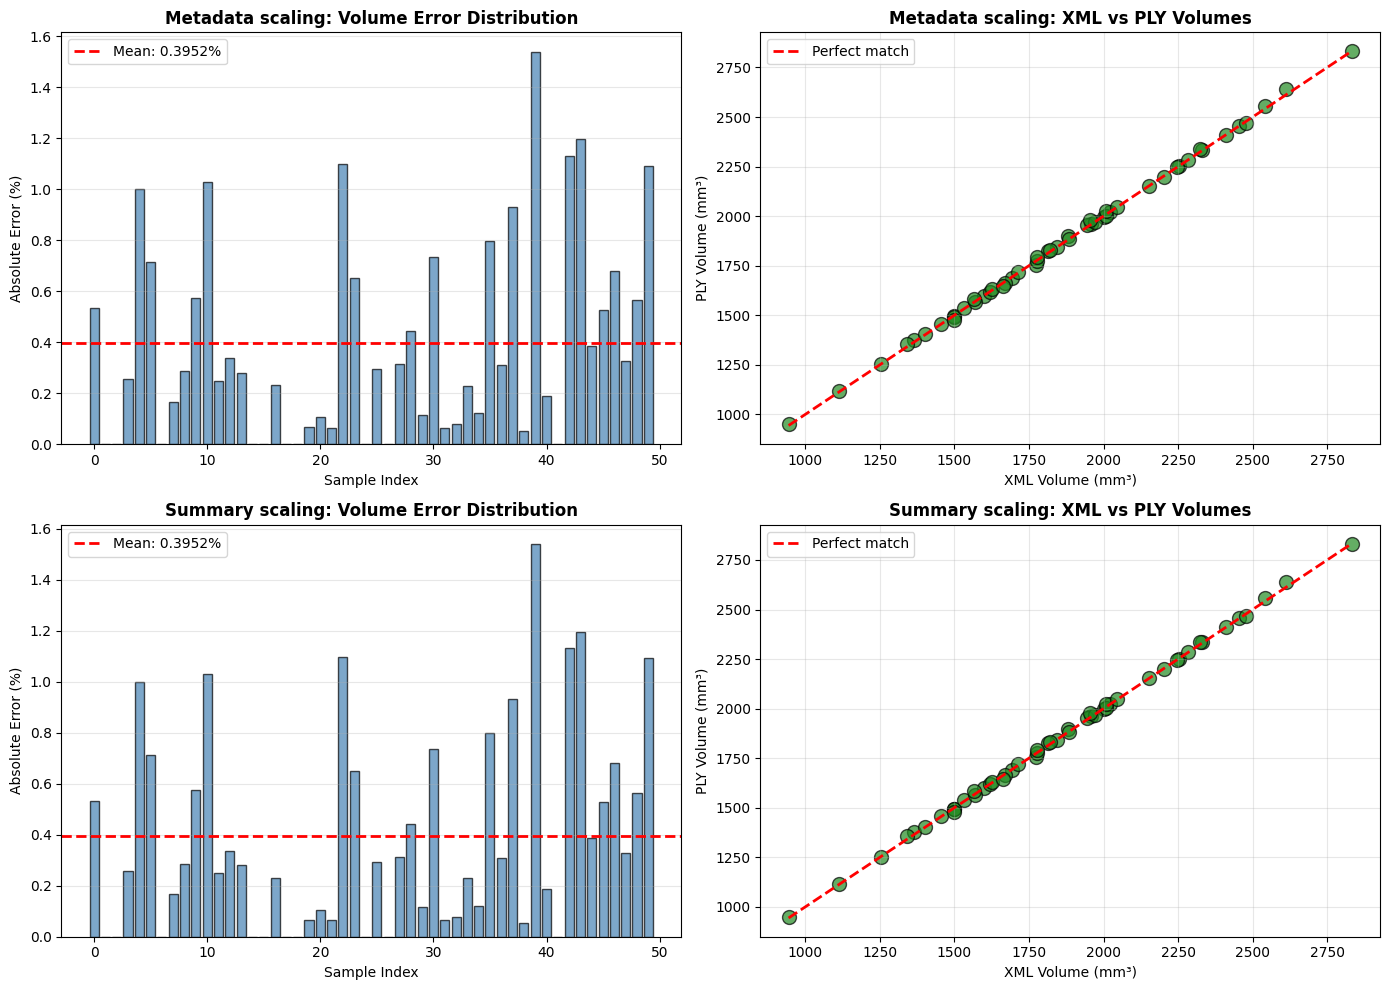


✓ Validation results saved to: /home/jakaria/ADNI/ADNI_1/adni_processed/left_hippocampus_correspondence/validation_50samples_compare.csv

VALIDATION COMPLETE
Metadata scaling -> ✓ EXCELLENT: Mean error < 1%, volume preservation is highly accurate
Summary scaling -> ✓ EXCELLENT: Mean error < 1%, volume preservation is highly accurate
✓ Compared scaling from metadata vs correspondence summary (left hippocampus)
✓ Using template medoid: I93352
✓ Deformetrica iterations: 20


In [25]:

# ============================================================================
# VALIDATION: Correspondence Results - Volume Preservation (50 Random Samples)
# Compare scaling factors: left metadata vs correspondence summary
# ============================================================================

import os
import random
import trimesh
import xml.etree.ElementTree as ET
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

print("="*80)
print("VALIDATION: CORRESPONDENCE RESULTS (50 RANDOM SAMPLES)")
print("="*80)

# Set paths
output_dir = "/home/jakaria/ADNI/ADNI_1/adni_processed/"
correspondence_dir = os.path.join(output_dir, "left_hippocampus_correspondence")
xml_metadata_path = "/home/jakaria/ADNI/ADNI_1/ADNI_1_Hippocampal_Mask_IDA_Metadata/ADNI"

# Load left hippocampus metadata to derive scale/unscale factors
left_ply_base = os.path.join(output_dir, "left_hippocampus_ply_rigid_reg")

def load_metadata(base_dir):
    metadata_csv = os.path.join(base_dir, "metadata.csv")
    if os.path.exists(metadata_csv):
        return pd.read_csv(metadata_csv).iloc[0]
    return None

left_metadata = load_metadata(left_ply_base)
metadata_volume_unscale = None
global_scale_factor = None

if left_metadata is not None:
    global_scale_factor = left_metadata['global_scale_factor']
    metadata_volume_unscale = (1 / global_scale_factor) ** 3
    print(f"\nLeft hippocampus scaling from metadata:")
    print(f"  global_scale_factor: {global_scale_factor:.8f}")
    print(f"  derived volume_unscale_factor (metadata): {metadata_volume_unscale:.6e}")
else:
    print(f"✗ Error: metadata.csv not found for left hippocampus at {os.path.join(left_ply_base, 'metadata.csv')}")

# Load correspondence summary metadata
summary_file = os.path.join(correspondence_dir, "minimal_summary.csv")
summary_volume_unscale = None
template_medoid = None
iterations = None

if not os.path.exists(summary_file):
    print(f"✗ Error: Summary file not found: {summary_file}")
else:
    summary_df = pd.read_csv(summary_file)
    summary_volume_unscale = summary_df['volume_unscale_factor'].values[0]
    template_medoid = summary_df['template_medoid'].values[0]
    iterations = summary_df['iterations'].values[0]

    print(f"\nCorrespondence Summary:")
    print(f"  Version: {summary_df['version'].values[0]}")
    print(f"  Template (medoid): {template_medoid}")
    print(f"  Iterations: {iterations}")
    print(f"  Total processed: {summary_df['successful'].values[0]}/{summary_df['total_input'].values[0]}")
    print(f"  Volume unscale (summary): {summary_volume_unscale:.6e}")

# Choose factors to compare
factors = {}
if metadata_volume_unscale is not None:
    factors['metadata'] = metadata_volume_unscale
if summary_volume_unscale is not None:
    factors['summary'] = summary_volume_unscale

if not factors:
    print("\n✗ Error: No volume unscale factors available; aborting validation.")
else:
    print("\nScaling factors to compare:")
    for name, factor in factors.items():
        print(f"  {name}: {factor:.6e}")

    # Helper functions
    def extract_image_id(filename):
        m = re.search(r'I\d+', filename)
        return m.group(0) if m else None

    def find_xml_by_id(image_id, xml_folder):
        for xml_file in glob(os.path.join(xml_folder, "*.xml")):
            if image_id in os.path.basename(xml_file):
                return xml_file
        return None

    def extract_volumes_from_xml(xml_file):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        ns = {'': 'http://www.loni.usc.edu/resource/xml/hippo/v1'}
        measures = root.findall('.//derivedMeasure', ns) or root.findall('.//derivedMeasure')

        vols = {}
        for m in measures:
            struct = m.find('.//measuredStructure', ns) or m.find('.//measuredStructure')
            if struct is not None and 'Hippocampus' in struct.text:
                hemi = m.find('.//measuredHemisphere', ns) or m.find('.//measuredHemisphere')
                val = m.find('.//measureValue', ns) or m.find('.//measureValue')
                if hemi is not None and val is not None:
                    vols[hemi.text.strip()] = float(val.text)
        return vols

    def calc_ply_volume(ply_file):
        try:
            mesh = trimesh.load(ply_file)
            return abs(mesh.volume)
        except Exception as e:
            print(f"  Error loading {os.path.basename(ply_file)}: {e}")
            return None

    # Get all correspondence PLY files
    correspondence_ply_dir = os.path.join(correspondence_dir, "minimal_final_ply")
    ply_files = sorted(glob(os.path.join(correspondence_ply_dir, "*.ply")))

    # Filter out template file if present
    ply_files = [f for f in ply_files if 'template' not in os.path.basename(f).lower()]

    print(f"\nCorrespondence PLY files found: {len(ply_files)}")

    if len(ply_files) == 0:
        print(f"✗ Error: No PLY files found in {correspondence_ply_dir}")
    else:
        # Select 50 random samples (fresh each run)
        n_samples = min(50, len(ply_files))
        sampled_files = random.sample(ply_files, n_samples)

        print(f"✓ Selected {n_samples} random samples for validation\n")

        # Validate samples
        validation_records = []

        for ply_file in tqdm(sampled_files, desc="Validating"):
            basename = os.path.basename(ply_file).replace('.ply', '')
            image_id = extract_image_id(basename)

            if not image_id:
                print(f"  Warning: Could not extract Image ID from {basename}")
                continue

            # Find XML file
            xml_file = find_xml_by_id(image_id, xml_metadata_path)
            if not xml_file:
                print(f"  Warning: XML not found for {image_id}")
                continue

            # Get ground truth volume
            xml_vols = extract_volumes_from_xml(xml_file)
            xml_left = xml_vols.get('Left')

            if xml_left is None:
                print(f"  Warning: Left volume not found in XML for {image_id}")
                continue

            # Calculate PLY volume
            vol_scaled = calc_ply_volume(ply_file)
            if vol_scaled is None:
                continue

            record = {
                'image_id': image_id,
                'xml_volume_mm3': xml_left,
            }

            # Compute per-factor volumes/errors
            for name, factor in factors.items():
                vol_mm3 = vol_scaled * factor
                error_mm3 = vol_mm3 - xml_left
                error_pct = abs(error_mm3) / xml_left * 100

                record[f'ply_volume_mm3_{name}'] = vol_mm3
                record[f'error_mm3_{name}'] = error_mm3
                record[f'error_pct_{name}'] = error_pct

            validation_records.append(record)

        # Create DataFrame
        results_df = pd.DataFrame(validation_records)

        # ==========================================================================
        # RESULTS SUMMARY
        # ==========================================================================
        print(f"\n{'='*80}")
        print("VALIDATION RESULTS")
        print(f"{'='*80}")

        if len(results_df) > 0:
            print(f"\nSamples validated: {len(results_df)}")

            # Stats per factor
            for name in factors.keys():
                vol_col = f'ply_volume_mm3_{name}'
                err_col = f'error_pct_{name}'
                if vol_col in results_df.columns:
                    print(f"\n{name.upper()} scaling:")
                    print(f"  PLY mean ± std: {results_df[vol_col].mean():.2f} ± {results_df[vol_col].std():.2f} mm³")
                    print(f"  Mean absolute error: {results_df[err_col].mean():.4f}%")
                    print(f"  Std dev: {results_df[err_col].std():.4f}%")
                    print(f"  Min error: {results_df[err_col].min():.4f}%")
                    print(f"  Max error: {results_df[err_col].max():.4f}%")

            # Display table
            print(f"\n{'='*80}")
            print("DETAILED RESULTS")
            print(f"{'='*80}")
            display_cols = ['image_id', 'xml_volume_mm3']
            for name in factors.keys():
                display_cols.extend([
                    f'ply_volume_mm3_{name}',
                    f'error_mm3_{name}',
                    f'error_pct_{name}'
                ])
            display_df = results_df[display_cols].copy()
            for col in display_df.columns:
                if 'error_pct' in col:
                    display_df[col] = display_df[col].round(4)
                elif 'error_mm3' in col:
                    display_df[col] = display_df[col].round(2)
                elif 'volume_mm3' in col:
                    display_df[col] = display_df[col].round(2)
            print(display_df.to_string(index=False))

            # ==========================================================================
            # VISUALIZATION
            # ==========================================================================
            print(f"\n{'='*80}")
            print("CREATING VISUALIZATION")
            print(f"{'='*80}")

            n_factors = len(factors)
            fig, axes = plt.subplots(n_factors, 2, figsize=(14, 5 * n_factors))
            if n_factors == 1:
                axes = np.array([axes])  # ensure 2D indexing

            for row, (name, factor) in enumerate(factors.items()):
                err_col = f'error_pct_{name}'
                vol_col = f'ply_volume_mm3_{name}'

                # Error distribution
                axes[row, 0].bar(range(len(results_df)), results_df[err_col], color='steelblue', edgecolor='black', alpha=0.7)
                axes[row, 0].axhline(results_df[err_col].mean(), color='red', linestyle='--', linewidth=2,
                                   label=f"Mean: {results_df[err_col].mean():.4f}%")
                axes[row, 0].set_title(f'{name.capitalize()} scaling: Volume Error Distribution', fontsize=12, fontweight='bold')
                axes[row, 0].set_xlabel('Sample Index')
                axes[row, 0].set_ylabel('Absolute Error (%)')
                axes[row, 0].legend()
                axes[row, 0].grid(alpha=0.3, axis='y')

                # Scatter: XML vs PLY
                axes[row, 1].scatter(results_df['xml_volume_mm3'], results_df[vol_col],
                                   s=100, alpha=0.7, color='forestgreen', edgecolor='black')
                min_vol = min(results_df['xml_volume_mm3'].min(), results_df[vol_col].min())
                max_vol = max(results_df['xml_volume_mm3'].max(), results_df[vol_col].max())
                axes[row, 1].plot([min_vol, max_vol], [min_vol, max_vol], 'r--', linewidth=2, label='Perfect match')
                axes[row, 1].set_title(f'{name.capitalize()} scaling: XML vs PLY Volumes', fontsize=12, fontweight='bold')
                axes[row, 1].set_xlabel('XML Volume (mm³)')
                axes[row, 1].set_ylabel('PLY Volume (mm³)')
                axes[row, 1].legend()
                axes[row, 1].grid(alpha=0.3)

            plt.tight_layout()
            plt.show()

            # ==========================================================================
            # SAVE RESULTS
            # ==========================================================================
            validation_csv = os.path.join(correspondence_dir, "validation_50samples_compare.csv")
            results_df.to_csv(validation_csv, index=False)
            print(f"\n✓ Validation results saved to: {validation_csv}")

            # Final verdict per factor
            print(f"\n{'='*80}")
            print("VALIDATION COMPLETE")
            print(f"{'='*80}")
            for name in factors.keys():
                err_col = f'error_pct_{name}'
                mean_err = results_df[err_col].mean()
                if mean_err < 1.0:
                    verdict = "✓ EXCELLENT: Mean error < 1%, volume preservation is highly accurate"
                elif mean_err < 2.0:
                    verdict = "✓ GOOD: Mean error < 2%, volume preservation is acceptable"
                else:
                    verdict = "⚠ WARNING: Mean error >= 2%, check volume correction process"
                print(f"{name.capitalize()} scaling -> {verdict}")

            print(f"✓ Compared scaling from metadata vs correspondence summary (left hippocampus)")
            print(f"✓ Using template medoid: {template_medoid or 'unknown'}")
            print(f"✓ Deformetrica iterations: {iterations if iterations is not None else 'unknown'}")
        else:
            print(f"\n✗ No valid samples to display")
